# Global Brain States and Hippocampus

Analysis notebook for *Memory and Hippocampal Responses to Event Boundaries are Modulated by Global Brain States* (Gözükara et al., 2026).

Code repo: https://github.com/drgzkr/global-states-event-memory

## 1. Setup

### 1.1 Install dependencies

In [39]:
!pip install -q nilearn gdown

# Install statesegmentation from the project's fork
!rm -rf statesegmentation
!git clone -q https://github.com/drgzkr/statesegmentation/
%cd statesegmentation/
!pip install -q .
%cd ..

/content/statesegmentation
  Preparing metadata (setup.py) ... done
/content


### 1.2 Download data from Google Drive

All pre-computed data is shared as individual files on Google Drive and downloaded with `gdown`. The two GSBS results folders are stored as `.zip` archives (one per dataset) to avoid `gdown`'s 50-file-per-folder limit, and are unzipped automatically here.


In [40]:
import os
import zipfile
import gdown

DATA_ROOT = '/content/project_data'
os.makedirs(DATA_ROOT, exist_ok=True)

# ── File IDs — replace each value with the real Google Drive file ID ─────────
FILE_IDS = {
    # Pre-extracted hippocampal timeseries (pickle files)
    'Sherlock_all_subs_hippocampus_response.pkl'      : '1w19iz-ourZjiwGJE5wYk538b4DguQpeP',
    'StudyForrest_all_subs_hippocampus_response.pkl'  : '1JstwDK3VRGPeaf0u15jhGh3-0VQMDq0S',
    # GSBS result archives (zip files — unzipped automatically below)
    'Sherlock_SingleSubGlobalGSBS_Results.zip'        : '11Gtq_hp14Fb3eBFRvpqelGouq-RDATnV',
    'StudyForrest_SingleSubGlobalGSBS_Results.zip'    : '10Mms7DyQ87mq-jS8W7KfscGmc5QZhdmk',
    # Annotation files
    'Sherlock_Annotations.zip'                        : '1YUy9uiy2wGnsUrDhKHN3x8AziafEeGpA',
    'StudyForrest_Annotations.zip'                    : '1uwDdPAHXSSo0ZrYn6UvJX71zwfh-gmwf',
}

# ── Download ──────────────────────────────────────────────────────────────────
for filename, file_id in FILE_IDS.items():
    dest = os.path.join(DATA_ROOT, filename)
    # Skip if already downloaded (or already unzipped for zips)
    unpacked = dest.replace('.zip', '')
    if os.path.exists(dest) or (filename.endswith('.zip') and os.path.exists(unpacked)):
        print(f'Already present, skipping: {filename}')
        continue
    print(f'Downloading {filename} ...')
    gdown.download(id=file_id, output=dest, quiet=False)

# ── Unzip archives ────────────────────────────────────────────────────────────
for filename in FILE_IDS:
    if not filename.endswith('.zip'):
        continue
    zip_path   = os.path.join(DATA_ROOT, filename)
    unzip_dest = zip_path.replace('.zip', '')
    if os.path.exists(unzip_dest):
        print(f'Already unzipped, skipping: {filename}')
        continue
    print(f'Unzipping {filename} ...')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(DATA_ROOT)
    os.remove(zip_path)   # free up disk space
    print(f'  → {unzip_dest}')

print('\nAll data ready.')
print('Contents of DATA_ROOT:')
for entry in sorted(os.listdir(DATA_ROOT)):
    full = os.path.join(DATA_ROOT, entry)
    if os.path.isdir(full):
        n = len(os.listdir(full))
        print(f'  {entry}/  ({n} files)')
    else:
        size_mb = os.path.getsize(full) / 1e6
        print(f'  {entry}  ({size_mb:.1f} MB)')

Already present, skipping: Sherlock_all_subs_hippocampus_response.pkl
Already present, skipping: StudyForrest_all_subs_hippocampus_response.pkl
Already present, skipping: Sherlock_SingleSubGlobalGSBS_Results.zip
Already present, skipping: StudyForrest_SingleSubGlobalGSBS_Results.zip
Already present, skipping: Sherlock_Annotations.zip
Already present, skipping: StudyForrest_Annotations.zip
Already unzipped, skipping: Sherlock_SingleSubGlobalGSBS_Results.zip
Already unzipped, skipping: StudyForrest_SingleSubGlobalGSBS_Results.zip
Already unzipped, skipping: Sherlock_Annotations.zip
Already unzipped, skipping: StudyForrest_Annotations.zip

All data ready.
Contents of DATA_ROOT:
  Sherlock_Annotations/  (2 files)
  Sherlock_SingleSubGlobalGSBS_Results/  (68 files)
  Sherlock_all_subs_hippocampus_response.pkl  (146.5 MB)
  StudyForrest_Annotations/  (8 files)
  StudyForrest_SingleSubGlobalGSBS_Results/  (120 files)
  StudyForrest_all_subs_hippocampus_response.pkl  (235.4 MB)
  figures/  (1 

### 1.3 Imports

In [41]:
import os
import time
import pickle
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
from scipy import stats
from scipy.stats import wilcoxon, zscore
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

from nilearn import plotting, image, surface, datasets
from nilearn.glm.first_level import make_first_level_design_matrix, run_glm

import statesegmentation

### 1.4 Output directories

In [42]:
now = datetime.now()
now_string = now.strftime('%Y_%m_%d_%H_%M_%S')

FIGURE_DIR = os.path.join(DATA_ROOT, 'figures', now_string)
NIFTI_DIR  = os.path.join(DATA_ROOT, 'niftis',  now_string)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(NIFTI_DIR,  exist_ok=True)

save_figures = True
print(f'Figures → {FIGURE_DIR}')
print(f'NIfTIs  → {NIFTI_DIR}')

Figures → /content/project_data/figures/2026_04_14_16_18_29
NIfTIs  → /content/project_data/niftis/2026_04_14_16_18_29


## 2. Parameters

### 2.1 Dataset selection

In [43]:
use_studyforrest = False
use_sherlock     = True

### 2.2 Analysis parameters

In [44]:
# ── Schaefer atlas ───────────────────────────────────────────────────────────
n_rois             = 400
yeo_networks       = 7
atlas_resolution_mm = 2

# ── FIR / event-window ───────────────────────────────────────────────────────
window_size = 21   # TRs, must be odd

# ── Boundary state classification ────────────────────────────────────────────
# A boundary is assigned to a state when that state occupies at least
# `TPN/DMN_bound_filter_threshold` of TRs in the window
# [-threshold_num_trs_pre_bound, +threshold_num_trs_post_bound] around it.
threshold_num_trs_pre_bound  = 3
threshold_num_trs_post_bound = 3
TPN_bound_filter_threshold   = 0.7
DMN_bound_filter_threshold   = 0.7

# ── DBSCAN clustering ────────────────────────────────────────────────────────
use_dbscan_across = True

# ── Figure style ─────────────────────────────────────────────────────────────
dpi               = 150
axis_label_fontsize = 12
axis_tick_fontsize  = 10
axis_edge_lw        = 1.5
plot_line_w         = 3
scatter_s           = 60
cscale = ['#B78D64', '#A4B161', '#3F6871', '#764177',
          '#754C24', '#657123', '#4A184C', '#183F48']

### 2.3 Dataset-specific config

In [45]:
if use_studyforrest:
    Dataset_name = 'StudyForrest'
    sub_list = ['sub-01','sub-02','sub-03','sub-04','sub-05','sub-06',
                'sub-09','sub-10','sub-14','sub-15','sub-16','sub-17',
                'sub-18','sub-19','sub-20']
    tr_dur = 2.0   # seconds
    runs   = [1,2,3,4,5,6,7,8]

if use_sherlock:
    Dataset_name = 'Sherlock'
    sub_list = ['1','2','3','4','5','6','7','8','9',
                '10','11','12','13','14','15','16','17']
    tr_dur = 1.5   # seconds
    runs   = [1,2]

print(f'Dataset : {Dataset_name}')
print(f'Subjects: {len(sub_list)}')
print(f'TR      : {tr_dur} s')

Dataset : Sherlock
Subjects: 17
TR      : 1.5 s


## 3. Schaefer Atlas

Load the Schaefer 400-ROI atlas via nilearn and build the network-membership masks needed to orient DBSCAN cluster labels (DMN vs TPN).

In [46]:
schaefer        = datasets.fetch_atlas_schaefer_2018(
    n_rois=n_rois, yeo_networks=yeo_networks, resolution_mm=atlas_resolution_mm)
atlas_img       = image.load_img(schaefer['maps'])
schaefer_labels = schaefer['labels']

# Decode bytes labels if necessary (nilearn sometimes returns bytes)
if isinstance(schaefer_labels[0], bytes):
    schaefer_labels = [lbl.decode('utf-8') for lbl in schaefer_labels]

# Network-membership masks used later for DMN/TPN orientation
DAN_ROIs_mask = ['DorsAttn' in lbl for lbl in schaefer_labels]
DMN_ROIs_mask = ['Default_Temp'  in lbl for lbl in schaefer_labels]
VIS_ROIs_mask = ['Vis'      in lbl for lbl in schaefer_labels]


print(f'Atlas ROIs: {len(schaefer_labels)}')
print(f'DAN ROIs : {sum(DAN_ROIs_mask)}')
print(f'DMN ROIs : {sum(DMN_ROIs_mask)}')
print(f'VIS ROIs : {sum(VIS_ROIs_mask)}')

[fetch_atlas_schaefer_2018] Dataset found in /root/nilearn_data/schaefer_2018

Atlas ROIs: 401
DAN ROIs : 46
DMN ROIs : 18
VIS ROIs : 61


## 4. Utility Functions

In [47]:
def roi_pattern_to_nifti(template,saving=False,output_path=''):
    # Load the template NIfTI file
    template_img = atlas_img
    template_data = template_img.get_fdata()

    # Create an empty array for the new image
    new_data = np.zeros_like(template_data)

    # Project ROI values onto the template
    unique_rois = np.unique(template_data)
    for roi_label in unique_rois:
        if roi_label == 0:  # Assuming 0 is the background
            continue
        if int(roi_label) - 1 < len(template):  # Ensure ROI index is within range
            new_data[template_data == roi_label] = template[int(roi_label) - 1]

    # Save the new NIfTI image
    new_img = nib.Nifti1Image(new_data, affine=template_img.affine, header=template_img.header)
    if saving:
        nib.save(new_img, output_path)
        print("New NIfTI image saved")
    return new_img


def long_plot(texture_left,texture_right,title='Title',fname = 'filename', saving=True,min_val=-1,max_val=1,views=['lateral', 'medial'],cmap='Spectral_r',norm=None,show=True):
    fsaverage = datasets.fetch_surf_fsaverage()
    # create a figure
    fig, axes = plt.subplots(1, 4, figsize=(15, 3), subplot_kw={'projection': '3d'})
    fig.suptitle(title, fontsize=12,x=0.45)

    # Define the views and hemispheres
    # views = ['lateral', 'medial']#, 'dorsal', 'ventral', 'anterior', 'posterior']
    hemispheres = ['left', 'right']
    from_left_to_right = [(views[0],hemispheres[0]), (views[0],hemispheres[1]), (views[1],hemispheres[0]), (views[1],hemispheres[1])]

    titles = {
      'lateral': 'Lateral View',
      'medial': 'Medial View',
      'dorsal': 'Dorsal View',
      'ventral': 'Ventral View',
      'anterior': 'Anterior View',
      'posterior': 'Posterior View'
    }

    if norm is None:
        norm = plt.Normalize(vmin=min_val, vmax=max_val)  # normalize based on min and max values


    # plot each view and hemisphere in subplots
    for i, (view, hemi) in enumerate(from_left_to_right):
        texture = texture_left if hemi == 'left' else texture_right
        ax = axes[i]
        plotting.plot_surf_stat_map(
          fsaverage.infl_left if hemi == 'left' else fsaverage.infl_right,
          texture,
          hemi=hemi,
          view=view,
          colorbar=False,  # Disable individual colorbars for a cleaner look
          bg_map=fsaverage.sulc_left if hemi == 'left' else fsaverage.sulc_right,
          cmap=cmap,
          axes=ax,
          vmax=max_val,
          vmin=min_val,
          bg_on_data = True
        )

    fig.subplots_adjust(top=1, right=0.85, wspace=0, hspace=0.00002, left=0.05, bottom=0)  # Adjust spacing

    cbar_ax = fig.add_axes([0.95, 0.05, 0.02, 0.8])  # (left, bottom, width, height)
    sm = plt.cm.ScalarMappable(cmap=cmap , norm=norm)
    sm.set_array([min_val, max_val])
    cbar = plt.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Metric', rotation=270, labelpad=15)  # Customize colorbar label

    if saving == True:
        plt.savefig(os.path.join(FIGURE_DIR,fname), transparent=True, dpi=300)
    if show:
        plt.show()


def nifti_to_surface(nifti_image):
    # load the fsaverage surface mesh
    fsaverage = datasets.fetch_surf_fsaverage()

    # smooth the volumetric image using
    # nifti_image = image.smooth_img(nifti_image, fwhm=5)

    # project the smooth 3D data onto the brain surface
    texture_left = surface.vol_to_surf(nifti_image, fsaverage.pial_left, interpolation='linear', radius=3.0, n_samples=20)
    texture_right = surface.vol_to_surf(nifti_image, fsaverage.pial_right, interpolation='linear', radius=3.0, n_samples=20)

    # set the values close to 0 to NaN for transparency
    lower_bound = -0.0005
    upper_bound = 0.0005
    texture_left[(texture_left >= lower_bound) & (texture_left <= upper_bound)] = np.nan
    texture_right[(texture_right >= lower_bound) & (texture_right <= upper_bound)] = np.nan
    return texture_left, texture_right

In [48]:
def export_legend(ax, filename='legend.png', **kwargs):
    legend = ax.get_legend()

    if legend is None:
        raise ValueError("No legend found on the axes")

    # Create a new figure just for the legend
    fig_legend = plt.figure()
    ax_legend = fig_legend.add_subplot(111)
    ax_legend.axis('off')

    # Get ALL handles and labels (including your custom text entries)
    handles, labels = ax.get_legend_handles_labels()

    # Recreate the legend with ALL entries
    new_legend = ax_legend.legend(handles, labels,
                                   loc='center',
                                   frameon=legend.get_frame_on())

    # Copy legend properties
    if legend.get_title():
        new_legend.set_title(legend.get_title().get_text())

    frame = legend.get_frame()
    new_frame = new_legend.get_frame()
    new_frame.set_facecolor(frame.get_facecolor())
    new_frame.set_edgecolor(frame.get_edgecolor())
    new_frame.set_alpha(frame.get_alpha())
    new_frame.set_linewidth(frame.get_linewidth())

    # Save with transparent background
    fig_legend.savefig(filename, bbox_inches='tight', transparent=True, **kwargs)
    plt.close(fig_legend)

def save_isolated_legend(handles, labels, filename="legend.png", **kwargs):
    """
    Saves a legend to a separate image file using the "New Figure" approach.

    Parameters:
    - handles: List of legend handles (lines, patches, etc.)
    - labels: List of legend label strings
    - filename: Output path
    - **kwargs: Additional arguments passed to plt.legend() (e.g., ncol, loc, prop)
    """
    # 1. Create a new "empty" figure.
    # We use a small size; bbox_inches='tight' will expand/contract it as needed.
    fig_leg, ax_leg = plt.subplots(figsize=(1, 1),dpi=dpi)

    # 2. Add the legend using the passed handles and labels
    # loc='center' ensures it's in the middle of our canvas before cropping
    ax_leg.legend(handles, labels, loc='center', **kwargs)

    # 3. Turn off the axis (removes the box around the plot area)
    ax_leg.axis('off')

    # 4. Save the figure
    # bbox_inches='tight' trims the empty space around the legend content
    fig_leg.savefig(filename, bbox_inches='tight', transparent=True)

    # Close the figure to free memory
    plt.close(fig_leg)

## 5. Hippocampus Data

### 5.1 Hippocampal mask

The hippocampal ROI timeseries was extracted using the WFU PickAtlas mask during preprocessing. The pre-extracted pickle files are loaded here; the mask itself is not needed at runtime.

In [49]:
# The hippocampal timeseries is loaded as a pre-extracted pickle below.
# If you need to re-extract from volumetric data, load the WFU PickAtlas
# hippocampal NIfTI mask from DATA_ROOT and resample it to match your data:
#
#   hippo_mask_path    = os.path.join(DATA_ROOT, 'masks', 'hippocampal_mask.nii')
#   hippo_mask_nifti   = image.load_img(hippo_mask_path)
#   hippo_mask_resamp  = image.resample_to_img(hippo_mask_nifti, atlas_img,
#                                               interpolation='nearest')
#   hippocampal_mask_data = hippo_mask_resamp.get_fdata()
print('Hippocampal mask note: timeseries loaded from pre-extracted pickles below.')

Hippocampal mask note: timeseries loaded from pre-extracted pickles below.


### 5.2 Load per-subject hippocampal timeseries

In [50]:
data_list_path = os.path.join(DATA_ROOT,
                    f'{Dataset_name}_all_subs_hippocampus_response.pkl')

if os.path.exists(data_list_path):
    with open(data_list_path, 'rb') as f:
        all_subs_concat_hippo_data = pickle.load(f)
    print(f'{Dataset_name} hippocampus data loaded  ({len(all_subs_concat_hippo_data)} subjects)')
else:
    raise FileNotFoundError(
        f'Hippocampus data not found at {data_list_path}.\n'
        'Make sure the Google Drive folder was downloaded correctly (Section 1.2).'
    )

Sherlock hippocampus data loaded  (17 subjects)


### 5.3 QC: subject-level hippocampal means

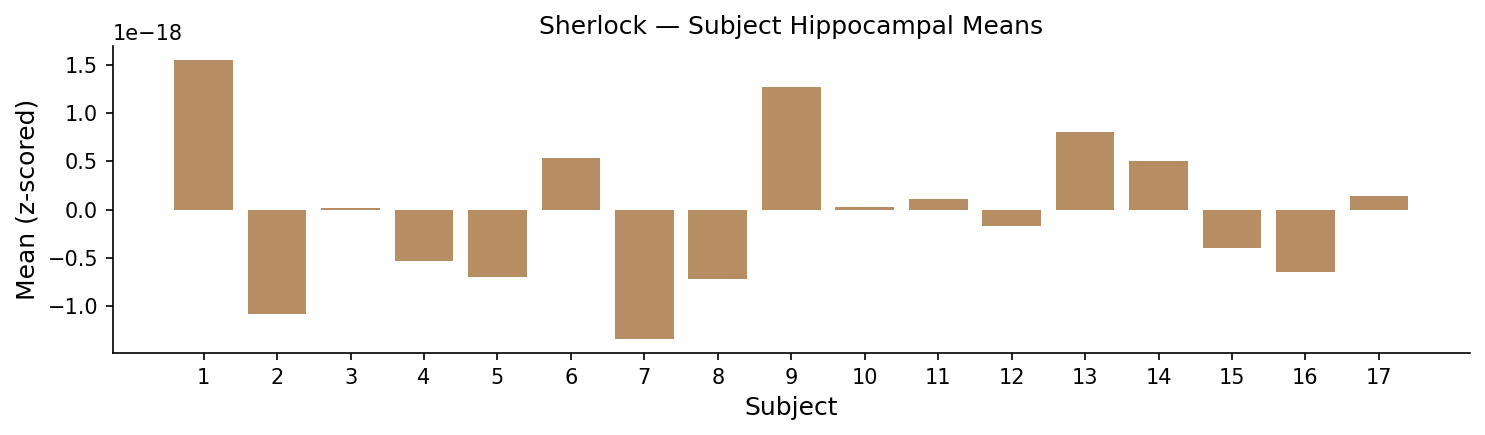

In [51]:
fig, ax = plt.subplots(figsize=(10, 3), dpi=dpi)
ax.bar(
    [sub.replace('sub-', '') for sub in sub_list],
    [np.mean(sub_hippo) for sub_hippo in all_subs_concat_hippo_data],
    color=cscale[0]
)
ax.set_title(f'{Dataset_name} — Subject Hippocampal Means')
ax.set_xlabel('Subject', fontsize=axis_label_fontsize)
ax.set_ylabel('Mean (z-scored)', fontsize=axis_label_fontsize)
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_hippo_subject_means.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

## 6. Event Boundaries

Load behavioural event boundary annotations. A 4.5 s offset is added to account for hemodynamic lag.

In [52]:
if use_studyforrest:
    # load gsbs objects for run lens
    all_subs_run_ROI_gsbs_objects = []

    for sub in tqdm(sub_list, desc='Loading GSBS objects'):
        run_gsbs_objects = []
        for run in runs:
            if use_studyforrest:
                path = os.path.join(
                    DATA_ROOT, 'StudyForrest_SingleSubGlobalGSBS_Results',
                    f'GSBS_{sub}_run{run}Schaefer_{n_rois}_ROIs.npy')
            else:  # sherlock
                path = os.path.join(
                    DATA_ROOT, 'Sherlock_SingleSubGlobalGSBS_Results',
                    f'Sherlock_GSBS_sub{sub}_run{run}_Schaefer_{n_rois}_ROIs.npy')
            run_gsbs_objects.append(np.load(path, allow_pickle=True).item())
        all_subs_run_ROI_gsbs_objects.append(run_gsbs_objects)

    # StudyForrest: boundaries defined by Ben-Yakov & Henson (2018)
    run_lens         = [obj.x.shape[0] for obj in all_subs_run_ROI_gsbs_objects[0]]
    cumsum_run_lens  = np.cumsum(run_lens)
    concat_event_bound_onsets = []
    for count, run in enumerate(runs):
        event_file_path = os.path.join(
            DATA_ROOT, 'StudyForrest_Annotations', f'events run{run}.tsv')
        event_file_data = np.genfromtxt(
            fname=event_file_path, delimiter='\t', skip_header=1)
        offsets = event_file_data[:, 0]
        if count > 0:
            offsets = offsets + cumsum_run_lens[count - 1] * tr_dur
        concat_event_bound_onsets.append(offsets)
    concat_event_bound_onsets = np.hstack(concat_event_bound_onsets)
    event_bounds_seconds = concat_event_bound_onsets + 4.5   # HRF lag
    event_bounds_tr      = np.floor(event_bounds_seconds / tr_dur).astype(int)

if use_sherlock:
    # Sherlock: 50 scene boundaries
    event_bounds_df  = pd.read_csv(
        os.path.join(DATA_ROOT, 'Sherlock_Annotations', 'movie_scenes_continued.csv'))
    event_bounds_tr      = np.array(event_bounds_df['Onset'])          # already in TRs
    event_bounds_seconds = event_bounds_tr * tr_dur

print(f'Event boundaries: {event_bounds_tr.shape[0]}')

Event boundaries: 50


## 7. Global Brain States (GSBS + DBSCAN)

### 7.1 Load pre-computed GSBS objects

In [53]:
all_subs_run_ROI_gsbs_objects = []

for sub in tqdm(sub_list, desc='Loading GSBS objects'):
    run_gsbs_objects = []
    for run in runs:
        if use_studyforrest:
            path = os.path.join(
                DATA_ROOT, 'StudyForrest_SingleSubGlobalGSBS_Results',
                f'GSBS_{sub}_run{run}Schaefer_{n_rois}_ROIs.npy')
        else:  # sherlock
            path = os.path.join(
                DATA_ROOT, 'Sherlock_SingleSubGlobalGSBS_Results',
                f'Sherlock_GSBS_sub{sub}_run{run}_Schaefer_{n_rois}_ROIs.npy')
        run_gsbs_objects.append(np.load(path, allow_pickle=True).item())
    all_subs_run_ROI_gsbs_objects.append(run_gsbs_objects)

print('Done.')

Loading GSBS objects: 100%|██████████| 17/17 [00:00<00:00, 23.81it/s]

Done.


> **StudyForrest users:** now re-run Section 6 to compute `event_bounds_tr` using the run lengths just loaded.

### 7.2 Inspect one subject's GSBS result

Subject 6, run 1 — nstates=69


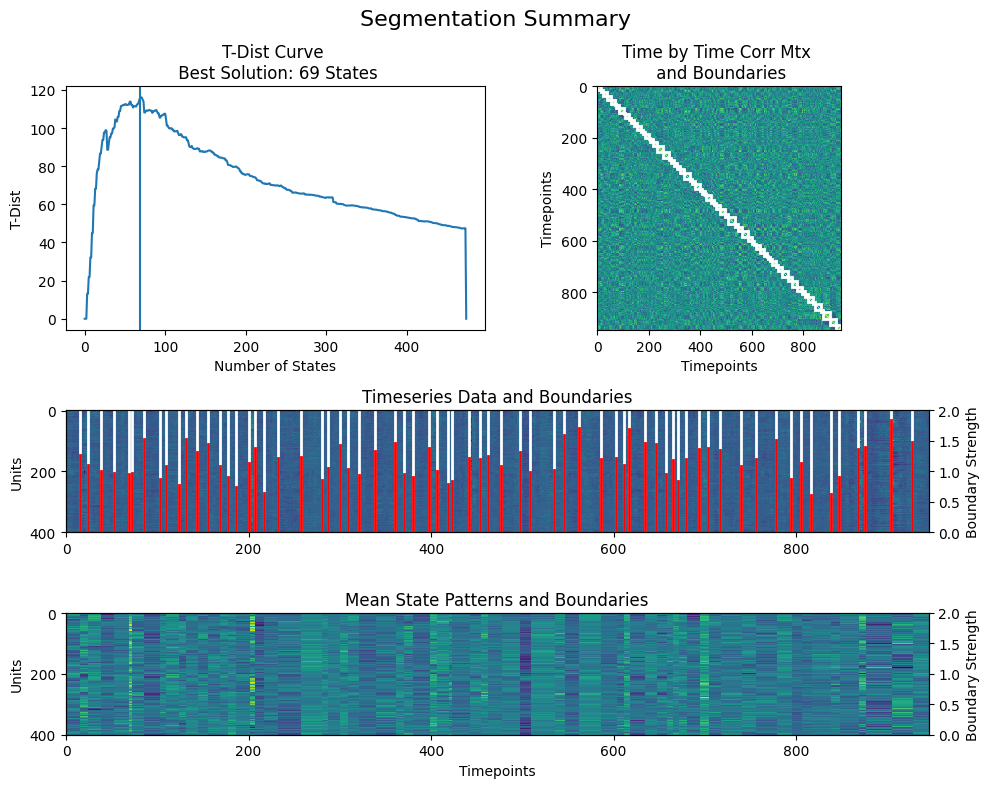

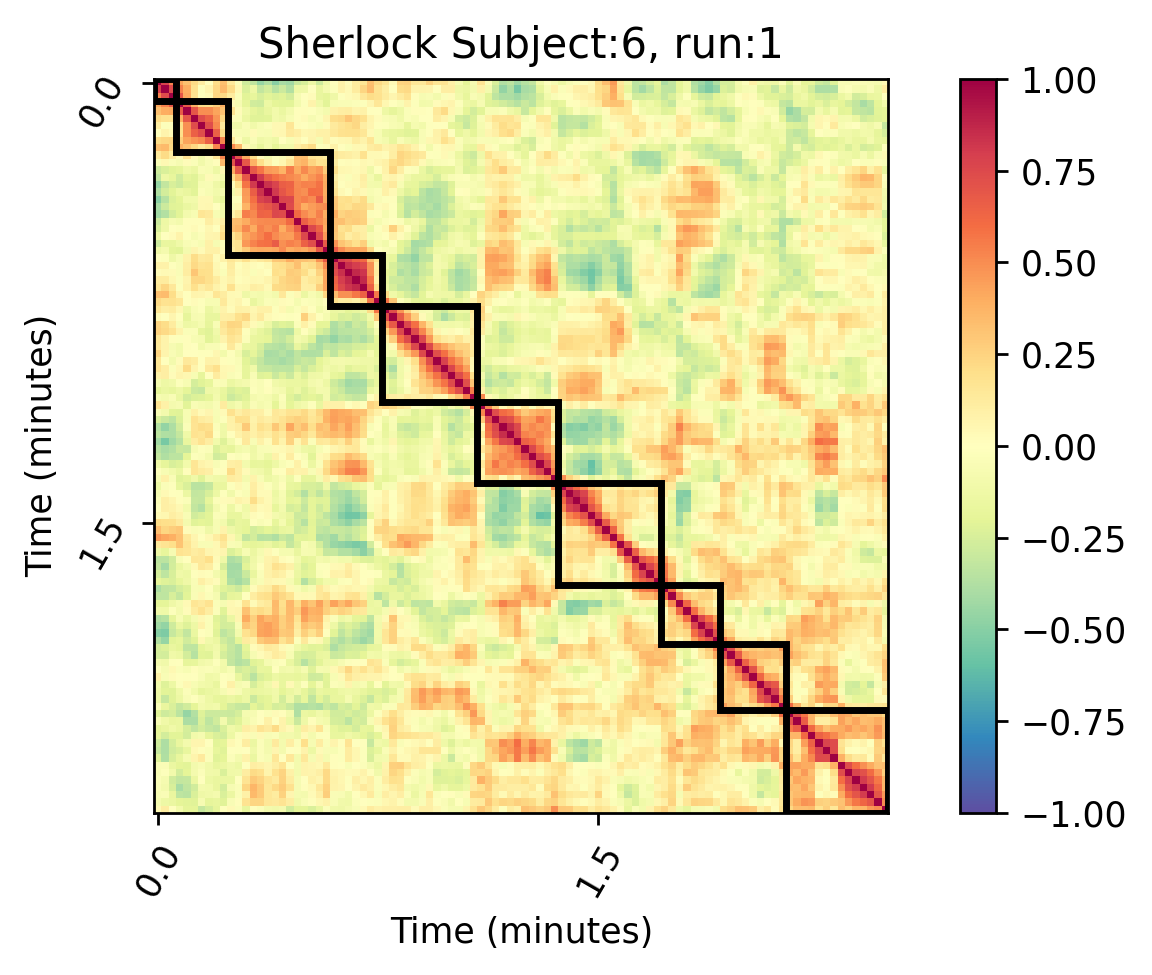

In [54]:
sub_index = 5
run_index = 0
sub_run_gsbs_object = all_subs_run_ROI_gsbs_objects[sub_index][run_index]
print(f'Subject {sub_list[sub_index]}, run {run_index + 1} — '
      f'nstates={sub_run_gsbs_object.nstates}')
sub_run_gsbs_object.plot_summary()

suptitle = f'{Dataset_name} Subject:{sub_list[sub_index]}, run:{run_index+1}'
sub_run_gsbs_object.plot_time_by_time_corr_mtx(
    title=suptitle,
    scale=2,
    fontsize=axis_tick_fontsize,
    line_color='black',
    line_width=2,
    color_map='Spectral_r',
    tr_in_seconds=tr_dur,
    time_tick_fraction=60,
    from_time=100,
    until_time=200,
    save_figures=save_figures,
    save_path=os.path.join(FIGURE_DIR, f'{Dataset_name}_gsbs_corr_matrix.png'),
    dpi=dpi,
)

### 7.3 GSBS quality metrics (per subject / run)

In [55]:
df_rows = []
for sub_id, runs in tqdm(zip(sub_list, all_subs_run_ROI_gsbs_objects)):
    for run_idx, g in enumerate(runs):
        max_tdist = np.max(g.tdists)
        td        = g.tdists[2:g.kmax + 2]
        post      = np.diff(td[g.nstates - 2:])
        strengths = g.strengths[g.strengths > 0]
        _, durs   = np.unique(g.states, return_counts=True)

        df_rows.append(dict(
            subject         = sub_id,
            run             = run_idx + 1,
            max_tdist       = max_tdist,
            nstates         = g.nstates,
            peak_mean_ratio = td.max() / td.mean(),
            frac_descent    = (post < 0).mean(),
            nstates_kmax    = g.nstates / g.kmax,
            dur_median      = np.median(durs),
            strength_mean   = strengths.mean(),
            strength_min    = strengths.min(),
        ))

gsbs_descriptives_df = pd.DataFrame(df_rows)

17it [00:03,  4.92it/s]


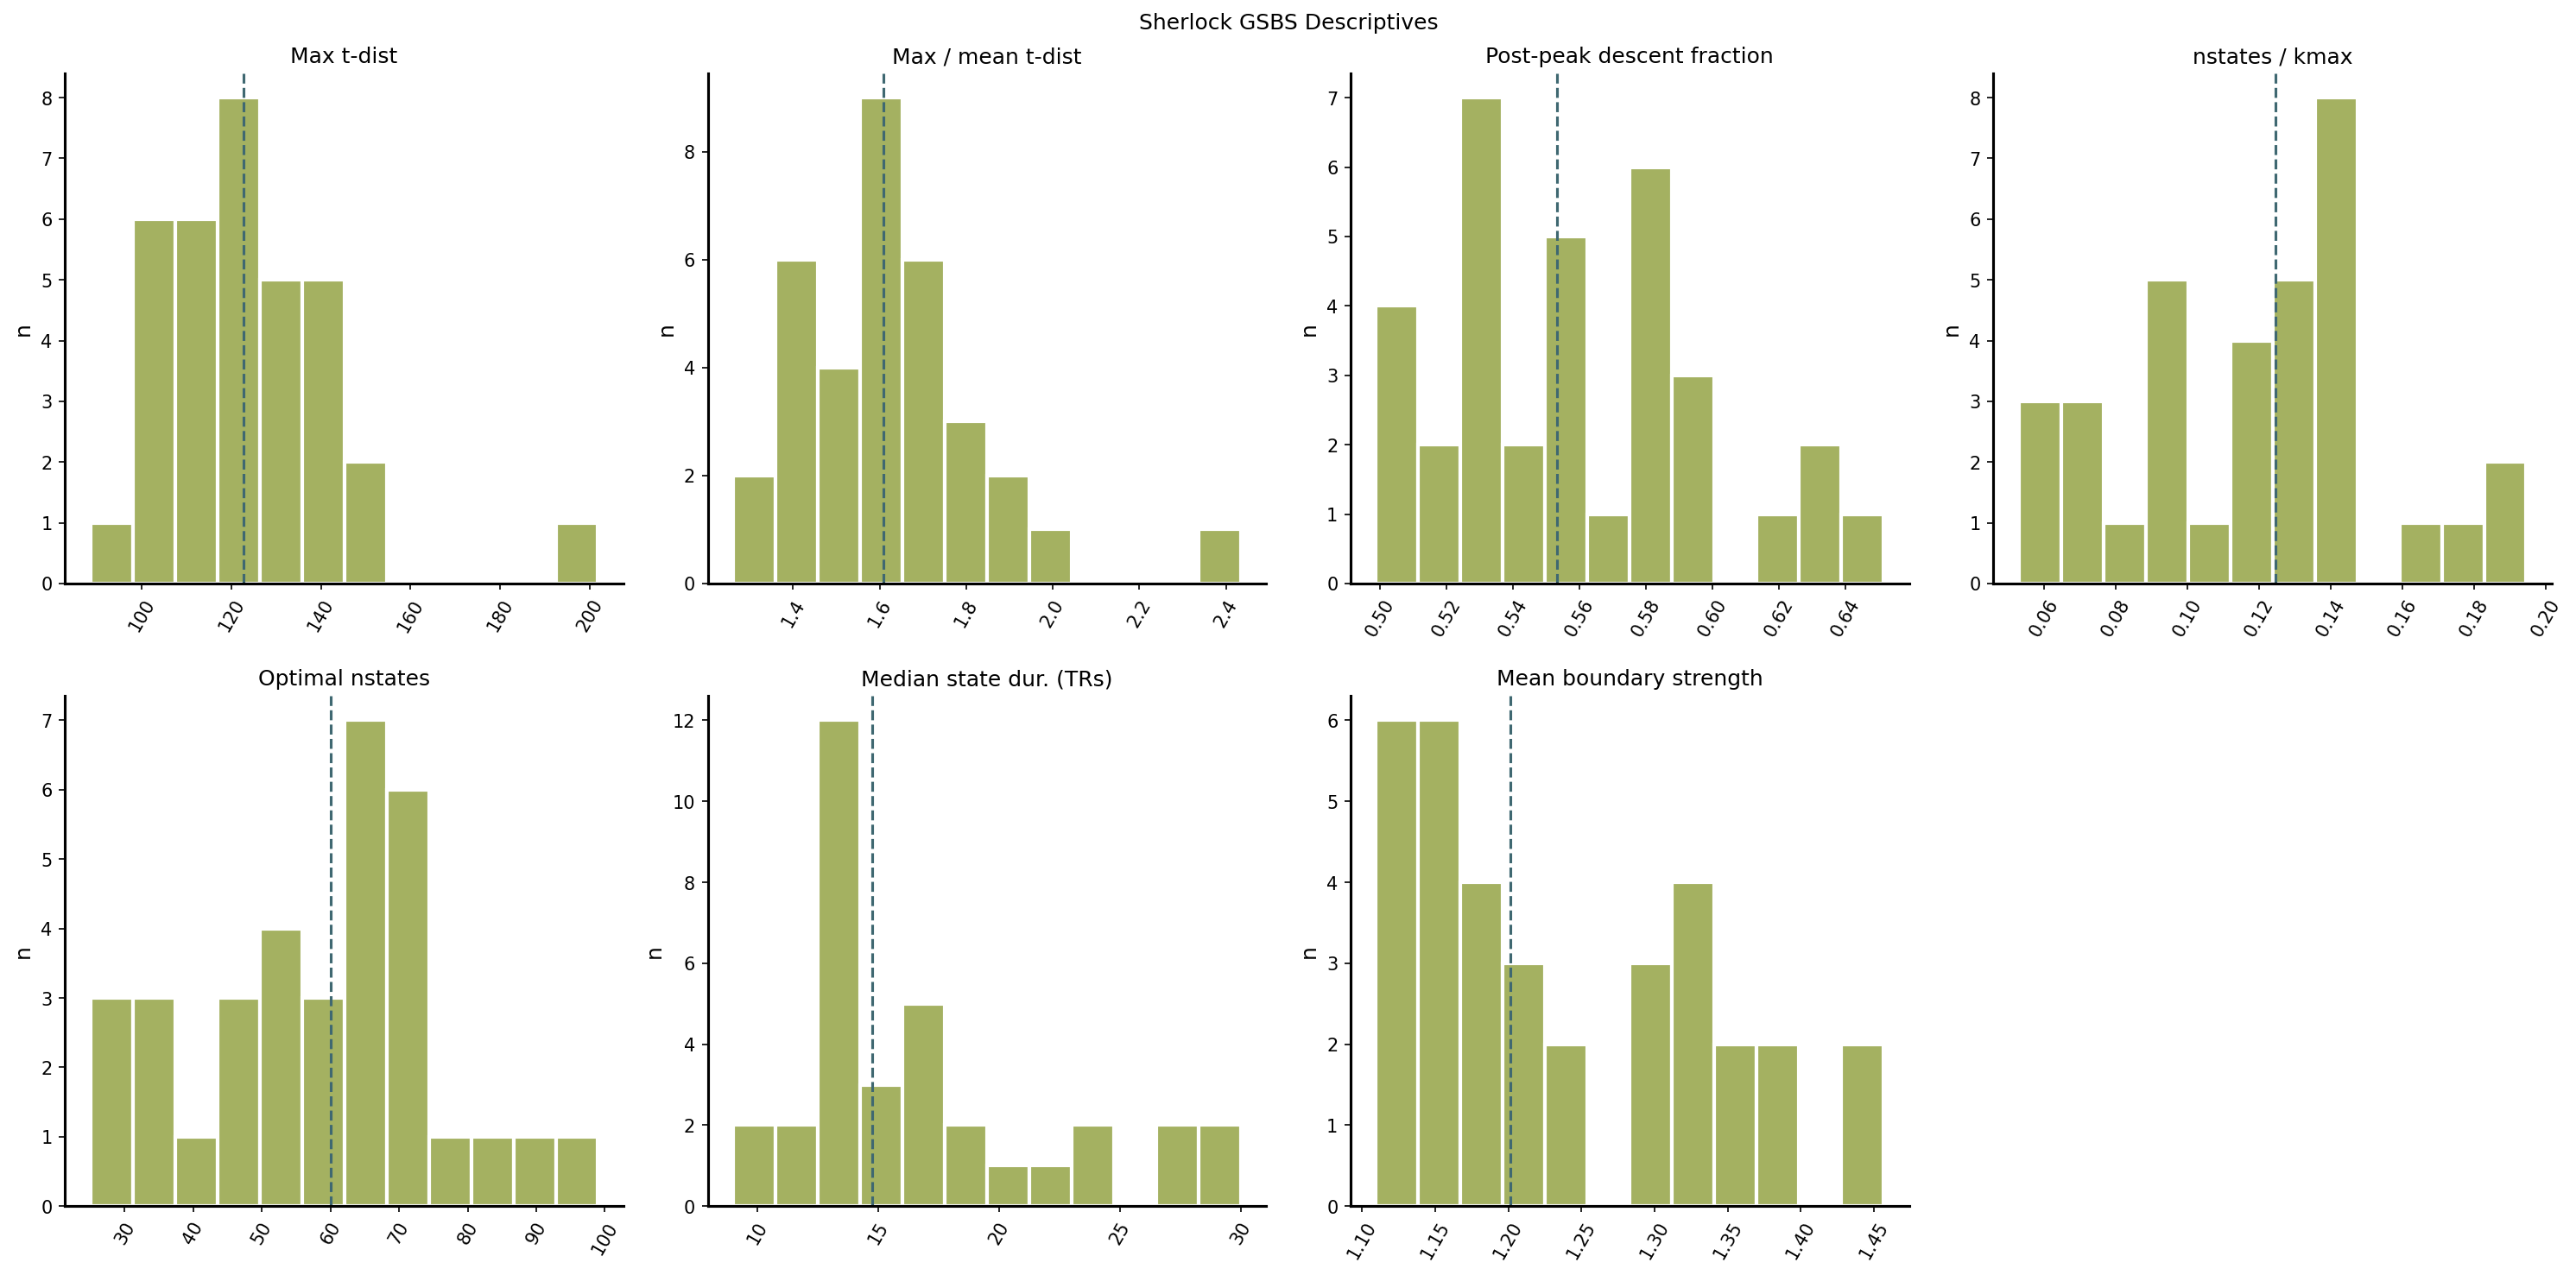

In [56]:
metrics = [
    ('max_tdist',         'Max t-dist'),
    ('peak_mean_ratio', 'Max / mean t-dist'),
    ('frac_descent',    'Post-peak descent fraction'),
    ('nstates_kmax',    'nstates / kmax'),
    ('nstates',         'Optimal nstates'),
    ('dur_median',      'Median state dur. (TRs)'),
    ('strength_mean',   'Mean boundary strength'),
    ('strength_min',    'Min boundary strength'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10),dpi=dpi)
# fig.subplots_adjust(hspace=0.45, wspace=0.35)

for ax, (col, title) in zip(axes.flat, metrics):
    vals = gsbs_descriptives_df[col].values
    ax.hist(vals, bins=12, color=cscale[1], edgecolor='white', linewidth=2)
    ax.axvline(np.median(vals), color=cscale[2], lw=1.5, ls='--')
    ax.set_title(title, fontsize=axis_label_fontsize)
    ax.set_ylabel('n', fontsize=axis_label_fontsize)
    ax.tick_params(labelsize=axis_tick_fontsize)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_linewidth(axis_edge_lw)
    ax.spines['bottom'].set_linewidth(axis_edge_lw)
    ax.yaxis.set_tick_params(labelsize=axis_tick_fontsize)
    ax.xaxis.set_tick_params(labelsize=axis_tick_fontsize,rotation=60)

axes.flat[-1].set_visible(False)

suptitle = f'{Dataset_name} GSBS Descriptives'
fig.suptitle(suptitle)
fig.tight_layout()

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_gsbs_descriptives.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')
plt.show()

### 7.4 LOO inter-subject reliability of GSBS boundaries

In [57]:
## Linda's LOO
all_runs_all_subs_sub_loo_reliabilies = []
for run_idx in range(len(runs)):
  all_subs_sub_loo_reliabilies = []
  for j in range(len(sub_list)):
    sub_j_deltas = all_subs_run_ROI_gsbs_objects[j][run_idx].deltas
    mean_loo_subs = np.zeros_like(sub_j_deltas)
    for i in range(len(sub_list)):
      if i == j:
        continue
      else:
        sub_i_deltas = all_subs_run_ROI_gsbs_objects[i][run_idx].deltas
        mean_loo_subs += sub_i_deltas
    mean_loo_subs = mean_loo_subs/len(sub_list)-1

    all_subs_sub_loo_reliabilies.append(np.corrcoef(mean_loo_subs,sub_j_deltas)[0][1])
  all_runs_all_subs_sub_loo_reliabilies.append(all_subs_sub_loo_reliabilies)

In [58]:
# Stats
res = wilcoxon(np.mean(all_runs_all_subs_sub_loo_reliabilies, axis=0),
               method='asymptotic')
print(f'{Dataset_name} LOO reliability — Wilcoxon z={abs(res.zstatistic):.3f}, p={res.pvalue:.4f}')
print(f'Mean r = {np.mean(all_runs_all_subs_sub_loo_reliabilies):.3f}, '
      f'SD = {np.std(np.mean(all_runs_all_subs_sub_loo_reliabilies, axis=0)):.3f}')

Sherlock LOO reliability — Wilcoxon z=3.621, p=0.0003
Mean r = 0.200, SD = 0.059


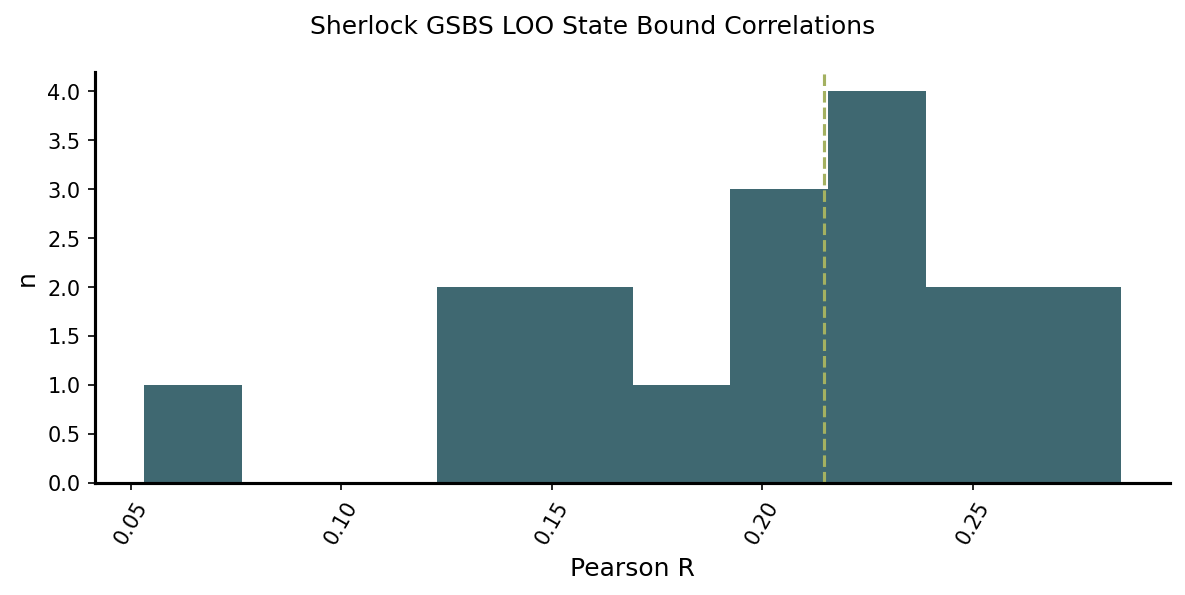

In [59]:
fig, ax = plt.subplots(figsize=(8, 4),dpi=dpi)

hist_values = np.mean(all_runs_all_subs_sub_loo_reliabilies,axis=0)
ax.hist(hist_values,color=cscale[2])

ax.axvline(np.median(hist_values), color=cscale[1], lw=1.5, ls='--')
# ax.set_title(title, fontsize=axis_label_fontsize)
ax.set_ylabel('n', fontsize=axis_label_fontsize)
ax.tick_params(labelsize=axis_tick_fontsize)
ax.set_xlabel('Pearson R',fontsize=axis_label_fontsize)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_linewidth(axis_edge_lw)
ax.spines['bottom'].set_linewidth(axis_edge_lw)
ax.yaxis.set_tick_params(labelsize=axis_tick_fontsize)
ax.xaxis.set_tick_params(labelsize=axis_tick_fontsize,rotation=60)

suptitle = f'{Dataset_name} GSBS LOO State Bound Correlations'
fig.suptitle(suptitle)
fig.tight_layout()

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_gsbs_loo_reliability.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

### 7.5 DBSCAN: cluster neural state patterns into DMN / TPN

> ⏱ This grid search takes **~2 minutes** for Sherlock and **~10 minutes** for StudyForrest on Colab (400 DBSCAN fits). Grab a coffee if you'd like; the progress bar will update for each `eps` value.

Outer Loop: 100%|██████████| 20/20 [01:14<00:00,  3.70s/it]


0.06210526315789474 2
Silhouete estimated number of clusters: 2
Silhouete estimated number of noise points: 1975
0.8436842105263158 738
Calinski-Harabasz estimated number of clusters: 2
Calinski-Harabasz estimated number of noise points: 0


100%|██████████| 17/17 [00:00<00:00, 196.38it/s]

CPU times: user 1min 53s, sys: 187 ms, total: 1min 53s
Wall time: 1min 15s


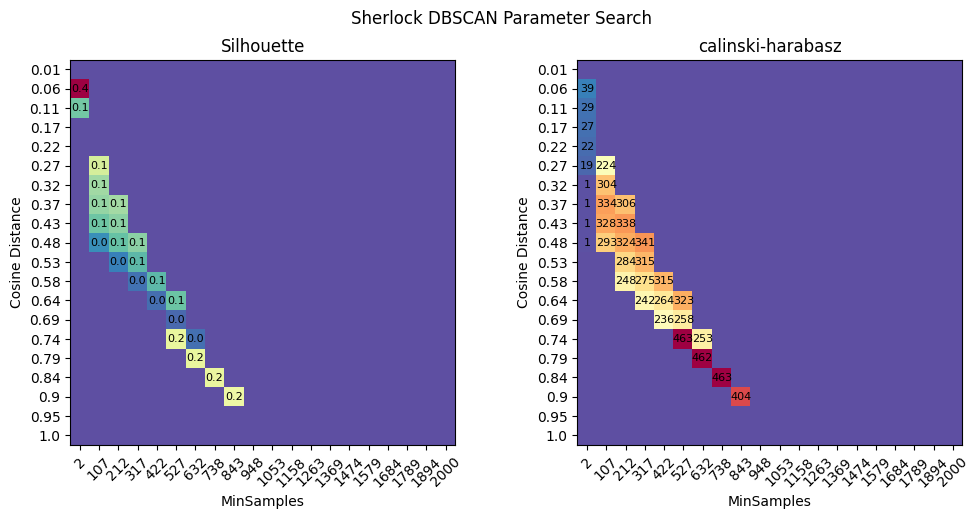

In [60]:
%%time

if use_dbscan_across:
    all_subs_concat_state_patterns = []
    all_subs_state_patterns_list = []
    for sub_all_runs_gsbs_objects in tqdm(all_subs_run_ROI_gsbs_objects):
        sub_state_patterns = []
        concat_state_pattens = []
        for run_gsbs_objects in sub_all_runs_gsbs_objects:
            concat_state_pattens.append(run_gsbs_objects.state_patterns)
        concat_state_pattens = np.vstack(concat_state_pattens)
        all_subs_concat_state_patterns.append(concat_state_pattens)
        all_subs_state_patterns_list.append(concat_state_pattens)
    all_subs_concat_state_patterns = np.vstack(all_subs_concat_state_patterns)
    all_subs_concat_state_patterns.shape

if use_dbscan_across:
    X = all_subs_concat_state_patterns

    eps_list = np.linspace(0.01,1,20)
    minsample_list = np.linspace(2,2000,20).astype(int)

    sil_scores = np.zeros((len(eps_list),len(minsample_list)))
    cal_scores = np.zeros((len(eps_list),len(minsample_list)))

    for eps_idx, eps in enumerate(tqdm(eps_list, desc="Outer Loop", leave=True,position=0)):
        for min_idx, minsamples in enumerate(minsample_list):
            db = DBSCAN(eps=eps, min_samples=minsamples,metric='cosine').fit(X)
            labels = db.labels_

            # Number of clusters in labels, ignoring noise if present.
            n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise_ = list(labels).count(-1)

            # Skip if all points are noise or in one cluster
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            if n_clusters < 2:
                sil_scores[eps_idx,min_idx] = -99
                cal_scores[eps_idx,min_idx] = -99
                continue

            sil_score = silhouette_score(X, labels)
            cal_score = calinski_harabasz_score(X, labels)

            sil_scores[eps_idx,min_idx] = sil_score
            cal_scores[eps_idx,min_idx] = cal_score


if use_dbscan_across:
    fig,axs=plt.subplots(1,2,figsize=(12,5))
    suptitle = f'{Dataset_name} DBSCAN Parameter Search'
    fig.suptitle(suptitle)
    axs[0].set_title('Silhouette')
    axs[0].imshow(sil_scores,aspect='equal',interpolation='none',vmin=0,vmax=np.max(sil_scores),cmap='Spectral_r')
    axs[0].set_ylabel('Cosine Distance')
    axs[0].set_yticks(np.linspace(0,len(eps_list)-1,len(eps_list)))
    axs[0].set_yticklabels(np.round(eps_list,2))
    axs[0].set_xlabel('MinSamples')
    axs[0].set_xticks(np.linspace(0,len(minsample_list)-1,len(minsample_list)))
    axs[0].set_xticklabels(minsample_list,rotation=45)
    # Annotate each cell with the correlation coefficient
    rows, cols = sil_scores.shape
    for i in range(rows):
        for j in range(cols):
            # Customize format (e.g., 2 decimal places)
            text = str(np.round(sil_scores[i, j],1))
            if sil_scores[i, j] >0:
                axs[0].text(j, i, text, ha='center', va='center', color='black',fontsize=8)
            else:
                axs[0].text(j, i, '', ha='center', va='center', color='white')


    axs[1].set_title('calinski-harabasz')
    axs[1].imshow(cal_scores,aspect='equal',interpolation='none',vmin=-1,vmax=np.max(cal_scores),cmap='Spectral_r')
    axs[1].set_ylabel('Cosine Distance')
    axs[1].set_yticks(np.linspace(0,len(eps_list)-1,len(eps_list)))
    axs[1].set_yticklabels(np.round(eps_list,2))
    axs[1].set_xlabel('MinSamples')
    axs[1].set_xticks(np.linspace(0,len(minsample_list)-1,len(minsample_list)))
    axs[1].set_xticklabels(minsample_list,rotation=45)
    # Annotate each cell with the correlation coefficient
    rows, cols = cal_scores.shape
    for i in range(rows):
        for j in range(cols):
            # Customize format (e.g., 2 decimal places)
            text = str(int(cal_scores[i, j]))
            if cal_scores[i, j] >0:
                axs[1].text(j, i, text, ha='center', va='center', color='black',fontsize=8)
            else:
                axs[1].text(j, i, '', ha='center', va='center', color='white')
    if save_figures:
        plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_dbscan_grid_search.png'),
                    transparent=True, dpi=dpi, bbox_inches='tight')

if use_dbscan_across:
    ## Silhouette
    best_eps = eps_list[np.unravel_index(np.argmax(sil_scores), sil_scores.shape)[0]]
    best_minsample =minsample_list[np.unravel_index(np.argmax(sil_scores), sil_scores.shape)[1]]
    print(best_eps,best_minsample)

    X = all_subs_concat_state_patterns

    db = DBSCAN(eps=best_eps, min_samples=best_minsample,metric='cosine').fit(X)
    labels = db.labels_

    # Number of clusters in labels, ignoring noise if present.
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)

    print("Silhouete estimated number of clusters: %d" % n_clusters_)
    print("Silhouete estimated number of noise points: %d" % n_noise_)


if use_dbscan_across:
    ## calinski-harabasz
    best_eps = eps_list[np.unravel_index(np.argmax(cal_scores), cal_scores.shape)[0]]
    best_minsample =minsample_list[np.unravel_index(np.argmax(cal_scores), cal_scores.shape)[1]]
    print(best_eps,best_minsample)

    X = all_subs_concat_state_patterns

    db = DBSCAN(eps=best_eps, min_samples=best_minsample,metric='cosine').fit(X)
    labels = db.labels_

    # Number of clusters in labels, ignoring noise if present.
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)

    print("Calinski-Harabasz estimated number of clusters: %d" % n_clusters_)
    print("Calinski-Harabasz estimated number of noise points: %d" % n_noise_)

if use_dbscan_across:
    all_sub_state_lens = []
    for sub_all_runs_gsbs_objects in tqdm(all_subs_run_ROI_gsbs_objects):
        sub_state_lens = 0
        for run_gsbs_objects in sub_all_runs_gsbs_objects:
            sub_state_lens +=run_gsbs_objects.state_patterns.shape[0]
        all_sub_state_lens.append(sub_state_lens)

    cumsum_all_sub_state_lens = np.insert(np.cumsum(all_sub_state_lens),0,0)

if use_dbscan_across:
    start_time = time.time()
    all_subs_tr_labels = []
    all_subs_cluster_patterns = []
    for sub_ind in range(len(sub_list)) :
        sub_run_ROI_gsbs_objects = all_subs_run_ROI_gsbs_objects[sub_ind]
        concat_global_bounds = []
        concat_global_state_patterns = []
        concat_state_lens = []
        for count, run_gsbs_obj in enumerate(sub_run_ROI_gsbs_objects):
            concat_global_bounds.append(np.insert(run_gsbs_obj.bounds, -1, 1))
            concat_global_bounds.append(run_gsbs_obj.bounds)
            concat_global_state_patterns.append(run_gsbs_obj.state_patterns)
            run_state_nums, run_state_lens = np.unique(run_gsbs_obj.states,return_counts=True)
            concat_state_lens.append(run_state_lens)

        concat_global_state_patterns = np.vstack(concat_global_state_patterns)
        concat_state_lens = np.hstack(concat_state_lens)
        concat_global_bounds = np.hstack(concat_global_bounds)


        sub_labels = labels[cumsum_all_sub_state_lens[sub_ind]: cumsum_all_sub_state_lens[sub_ind+1]]

        tr_labels = np.hstack([np.repeat(label,state_len) for label, state_len in zip(sub_labels,concat_state_lens)])
        cluster_patterns = np.array([np.mean(concat_global_state_patterns[sub_labels == state], axis=0) for state in range(2)])

        if np.sum(cluster_patterns[0][DAN_ROIs_mask]) > np.sum(cluster_patterns[0][DMN_ROIs_mask]):
            print(f'Subject{sub_list[sub_ind]} Label 0: TPN','Swapping Labels...' )
            tr_labels = (tr_labels - 1) * -1
            cluster_patterns = np.flip(cluster_patterns, axis=0)

        all_subs_tr_labels.append(tr_labels)
        all_subs_cluster_patterns.append(cluster_patterns)

### 7.6 Visualise state timeseries

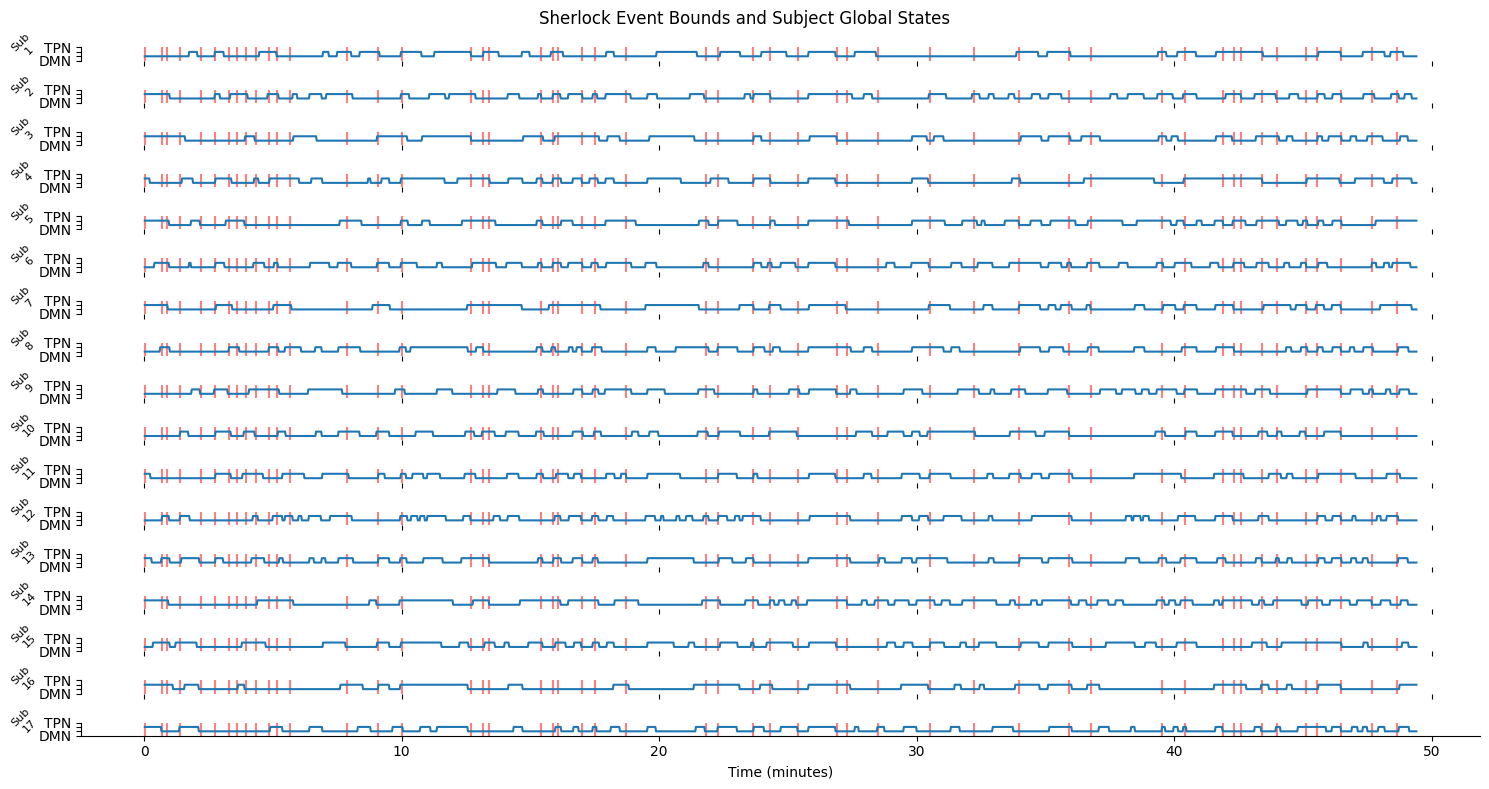

In [61]:
fig,axs = plt.subplots(len(sub_list),figsize=(15,8),sharex=True)
suptitle = f'{Dataset_name} Event Bounds and Subject Global States'
fig.suptitle(suptitle)
for sub_count, sub_tr_labels in enumerate(all_subs_tr_labels):
    timeline_in_minutes = (np.linspace(1,len(sub_tr_labels),len(sub_tr_labels))*tr_dur)/60
    axs[sub_count].plot(timeline_in_minutes,sub_tr_labels)
    axs[sub_count].set_ylabel(f'Sub\n{sub_list[sub_count]}',fontsize=8,rotation=45)
    # Get current ticks
    yticks = axs[sub_count].get_yticks()
    # # Replace first and last tick labels
    yticklabels = [str(np.round(t,0)) for t in yticks]
    yticklabels[0] = "DMN"
    yticklabels[-1] = "TPN"
    yticklabels[1] = ""
    yticklabels[2] = ""

    axs[sub_count].set_yticks(yticks)
    axs[sub_count].set_yticklabels(yticklabels)

    for event_bound in event_bounds_seconds:
        axs[sub_count].axvline(event_bound/60,color='red',alpha=0.5,zorder=0)
    # axs[sub_count].eventplot(event_bounds_seconds/60,color='red',alpha=0.5) # plot in minutes

    if sub_count < len(all_subs_tr_labels)-1:
        axs[sub_count].spines['top'].set_visible(False)  # Remove top border
        axs[sub_count].spines['right'].set_visible(False)  # Remove right border
        axs[sub_count].spines['bottom'].set_visible(False)  # Remove bottom border
    else:
        axs[sub_count].spines['top'].set_visible(False)  # Remove top border
        axs[sub_count].spines['right'].set_visible(False)  # Remove right border
        axs[sub_count].set_xlabel('Time (minutes)')

fig.tight_layout()

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_state_timeseries.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

### 7.7 Save and Plot Cluster Map Niftis

In [62]:
############## COME BACK AFTER UPLOADING REFERENCE NIFTIS
all_subs_cluster_patterns = np.array(all_subs_cluster_patterns)
mean_gsbs_unique_cluster_1 = zscore(np.mean(all_subs_cluster_patterns,axis=0)[0,1:])
mean_gsbs_unique_cluster_2 = zscore(np.mean(all_subs_cluster_patterns,axis=0)[1,1:])

print(f'{Dataset_name} Saving Unique GSBS State Cortical Maps')
gsbs_unique_cluster_1_nifti = roi_pattern_to_nifti(mean_gsbs_unique_cluster_1,saving=True,output_path=os.path.join(NIFTI_DIR, f'{Dataset_name}_GSBS_Unique_Cluster_1'))
gsbs_unique_cluster_2_nifti = roi_pattern_to_nifti(mean_gsbs_unique_cluster_2,saving=True,output_path=os.path.join(NIFTI_DIR, f'{Dataset_name}_GSBS_Unique_Cluster_2'))



Sherlock Saving Unique GSBS State Cortical Maps
New NIfTI image saved
New NIfTI image saved


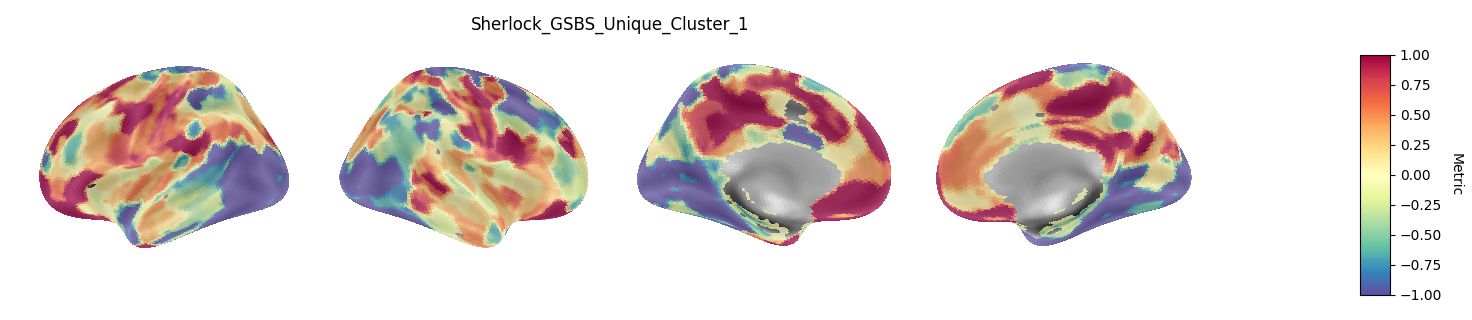

In [63]:

texture_left,texture_right = nifti_to_surface(gsbs_unique_cluster_1_nifti)
long_plot(texture_left,texture_right,title=f"{Dataset_name}_GSBS_Unique_Cluster_1",fname=f"{Dataset_name}_GSBS_Unique_Cluster_1",saving=True,min_val=-1,max_val=1,cmap='Spectral_r',views=['lateral', 'medial'])



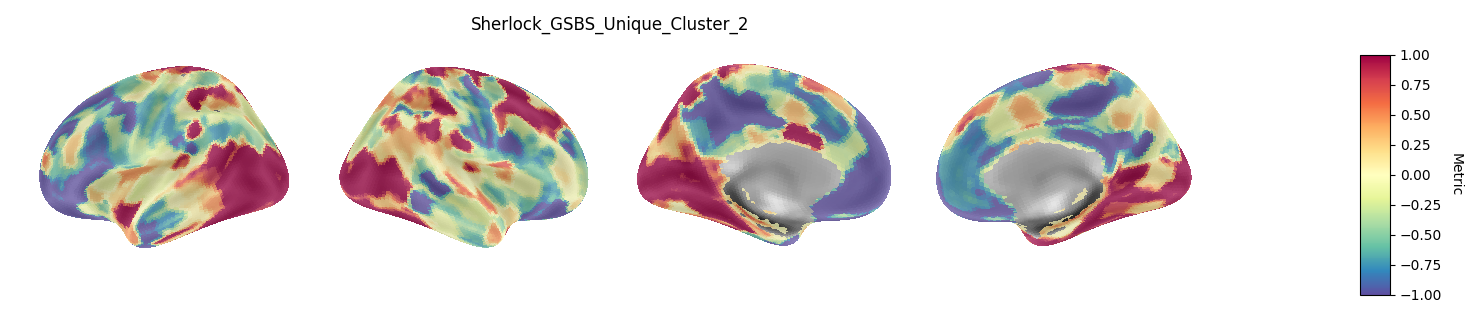

In [64]:
texture_left,texture_right = nifti_to_surface(gsbs_unique_cluster_2_nifti)
long_plot(texture_left,texture_right,title=f"{Dataset_name}_GSBS_Unique_Cluster_2",fname=f"{Dataset_name}_GSBS_Unique_Cluster_1",saving=True,min_val=-1,max_val=1,cmap='Spectral_r',views=['lateral', 'medial'])


In [65]:
## Calculate similarity to Anti-Correlated Template

# anti_corr_template_path = '///data/2025_multiscale_anticorrelated_template.nii'
# anti_corr_template_nifti = image.load_img(anti_corr_template_path)
# anti_corr_template_nifti_data = anti_corr_template_nifti.get_fdata()

# anti_corr_template = np.load('2025_multiscale_anticorrelated_template.npy')

# state1_template_correlation = np.corrcoef(anti_corr_template,mean_gsbs_unique_state_1)[0][1]
# state2_template_correlation = np.corrcoef(anti_corr_template,mean_gsbs_unique_state_2)[0][1]

# print(f"Cluster 1's similarity (Pearson R) to the anti-correlated template is {np.round(state1_template_correlation,2)}. Cluster 2's similarity (Pearson R) to the anti-correlated template is {np.round(state2_template_correlation,2)}.")

## 8. State Occurrence Statistics

Sherlock TPN - DMN Hippo Time
Wilcoxon Signed-rank Test
z stat:-3.574027065900189, p-value:0.0003515325685074632
Mean Event Boundary GLM Beta Across Subjects: -0.20689449869016432
Std Event Boundary GLM Beta Across Subjects: 0.07699203081969506


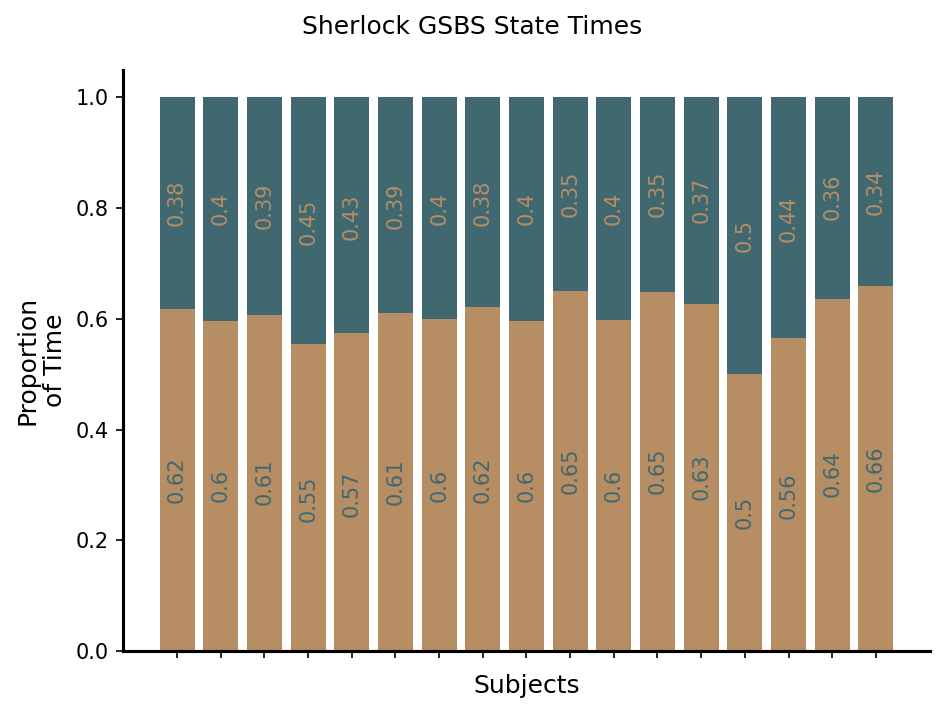

In [66]:
fig, axs = plt.subplots(dpi=dpi)
suptitle = f'{Dataset_name} GSBS State Times'
fig.suptitle(suptitle)
# Set width of bars
barWidth = 0.8

# Make the plot
axs.bar([sub.replace('sub-','') for sub in sub_list], [sub_tr_labels[sub_tr_labels==0].shape[0]/sub_tr_labels.shape[0] for sub_tr_labels in all_subs_tr_labels], width=barWidth, color=cscale[0], label='DMN')
axs.bar([sub.replace('sub-','') for sub in sub_list], [sub_tr_labels[sub_tr_labels==1].shape[0]/sub_tr_labels.shape[0] for sub_tr_labels in all_subs_tr_labels], bottom=[sub_tr_labels[sub_tr_labels==0].shape[0]/sub_tr_labels.shape[0] for sub_tr_labels in all_subs_tr_labels], width=barWidth, color=cscale[2], label='TPN')

x = [sub.replace('sub-','') for sub in sub_list]
a = [sub_tr_labels[sub_tr_labels==0].shape[0]/sub_tr_labels.shape[0] for sub_tr_labels in all_subs_tr_labels]
b = [sub_tr_labels[sub_tr_labels==1].shape[0]/sub_tr_labels.shape[0] for sub_tr_labels in all_subs_tr_labels]
# add labels in the middle of each segment
for idx, xi in enumerate(x):
    ai = np.round(a[idx],2)
    bi = np.round(b[idx],2)

    # segment A
    axs.text(xi, ai/2, str(ai), ha='center', va='center',color=cscale[2],rotation=90)

    # segment B
    axs.text(xi, ai + bi/2, str(bi), ha='center', va='center',color=cscale[0],rotation=90)
axs.yaxis.set_tick_params(labelsize=axis_tick_fontsize)
axs.xaxis.set_tick_params(labelsize=axis_tick_fontsize,rotation=60)
axs.set_xticklabels([])
axs.set_ylabel("Proportion\nof Time",fontsize=axis_label_fontsize)
axs.set_xlabel("Subjects",fontsize=axis_label_fontsize)

axs.spines['left'].set_linewidth(axis_edge_lw)
axs.spines['bottom'].set_linewidth(axis_edge_lw)
axs.spines['top'].set_visible(False)  # Remove top border
axs.spines['right'].set_visible(False)  # Remove right border

# axs.grid(True,zorder=1)
fig.tight_layout()

all_subs_dmn_time = np.array([sub_tr_labels[sub_tr_labels==0].shape[0]/sub_tr_labels.shape[0] for sub_tr_labels in all_subs_tr_labels])
all_subs_tpn_time = np.array([sub_tr_labels[sub_tr_labels==1].shape[0]/sub_tr_labels.shape[0] for sub_tr_labels in all_subs_tr_labels])
tpn_minus_dmn_hippo_time = all_subs_tpn_time - all_subs_dmn_time

res = wilcoxon(tpn_minus_dmn_hippo_time, method='asymptotic')
print(f'{Dataset_name} TPN - DMN Hippo Time')
print(f'Wilcoxon Signed-rank Test\nz stat:{res.zstatistic}, p-value:{res.pvalue}')

print(f'Mean Event Boundary GLM Beta Across Subjects: {np.mean(tpn_minus_dmn_hippo_time)}\nStd Event Boundary GLM Beta Across Subjects: {np.std(tpn_minus_dmn_hippo_time)}')

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_state_occurrence.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

## 9. Hippocampus at Event Boundaries

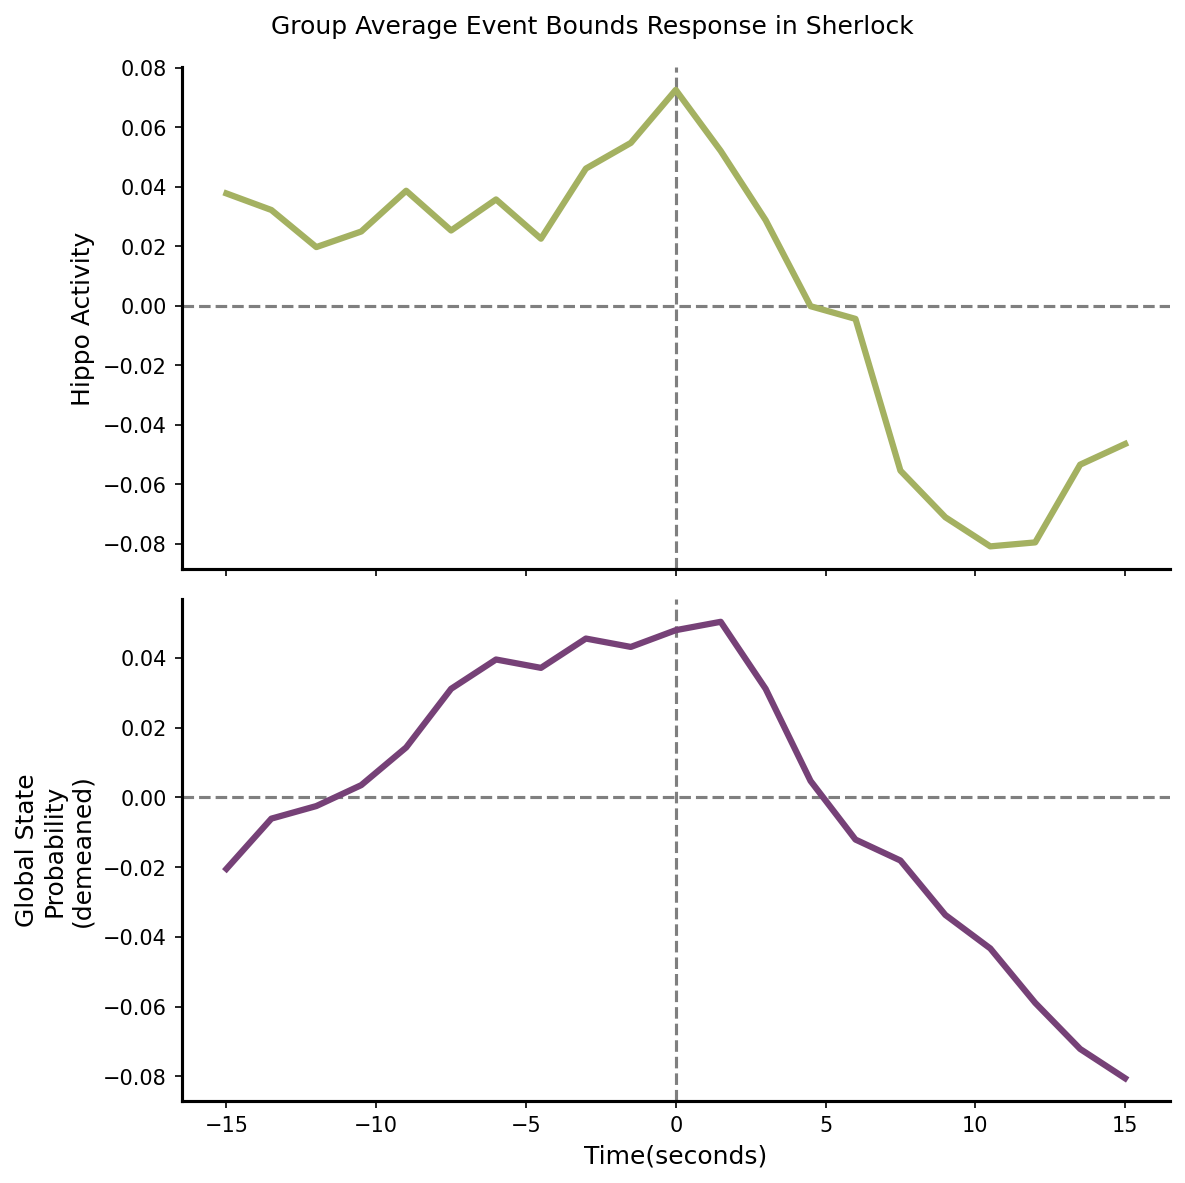

In [67]:
window = np.linspace(-(window_size-1)/2,(window_size-1)/2,window_size).astype(int)

all_subs_event_window_hippos = []
all_subs_event_window_gstates = []
for sub_idx in range(len(sub_list)):
    sub_event_window_hippos = []
    sub_event_window_gstates = []
    for bound in event_bounds_tr:
        if (bound >= int(window_size/2)) and (bound+int(window_size/2))<(all_subs_concat_hippo_data[sub_idx].shape[1]):
            bound_window = bound+window
            bound_window_hippo = all_subs_concat_hippo_data[sub_idx][:,bound_window]
            mean_bound_window_hippo = np.mean(bound_window_hippo,axis=0)
            sub_event_window_hippos.append(mean_bound_window_hippo)

            bound_window_gstates = all_subs_tr_labels[sub_idx][bound_window]
            sub_event_window_gstates.append(bound_window_gstates)

    all_subs_event_window_hippos.append(sub_event_window_hippos)
    all_subs_event_window_gstates.append(sub_event_window_gstates)

fig, axs = plt.subplots(2,1,figsize=(8,8),sharex=True,dpi=dpi)
suptitle = f'Group Average Event Bounds Response in {Dataset_name}'
fig.suptitle(suptitle)

axs[0].plot(window*tr_dur,np.mean(np.mean(all_subs_event_window_hippos,axis=0),axis=0),alpha=1,color=cscale[1],lw=plot_line_w)
axs[0].set_ylabel('Hippo Activity',fontsize=axis_label_fontsize)
axs[0].axvline(0,ls='--',zorder=0,color='black',alpha=0.5)
axs[0].axhline(0,ls='--',zorder=0,color='black',alpha=0.5)
axs[0].spines['top'].set_visible(False)  # Remove top border
axs[0].spines['right'].set_visible(False)  # Remove right border

axs[0].spines['left'].set_linewidth(axis_edge_lw)
axs[0].spines['bottom'].set_linewidth(axis_edge_lw)
axs[0].yaxis.set_tick_params(labelsize=axis_tick_fontsize)

# axs[0].spines['bottom'].set_visible(False)
# By demeaning, 0 is baseline for each subject, and not 50/50
# Am unsure about demeaning!!!!!
demeaned_all_subs_event_window_gstates = (np.array(all_subs_event_window_gstates) - np.mean(np.array(all_subs_event_window_gstates),axis=(1,2))[:,None,None])
axs[1].plot(window*tr_dur,np.mean(np.mean(demeaned_all_subs_event_window_gstates,axis=0),axis=0),alpha=1,color=cscale[3],lw=plot_line_w)
# axs[1].plot(window*tr_dur,np.mean(np.mean(all_subs_event_window_gstates,axis=0),axis=0),alpha=1,color=cscale[1],lw=5)
axs[1].set_xlabel('Time(seconds)',fontsize=axis_label_fontsize)
axs[1].set_ylabel('Global State\nProbability\n(demeaned)',fontsize=axis_label_fontsize)
axs[1].spines['top'].set_visible(False)  # Remove top border
axs[1].spines['right'].set_visible(False)  # Remove right border

axs[1].axvline(0,ls='--',zorder=0,color='black',alpha=0.5)
axs[1].axhline(0,ls='--',zorder=0,color='black',alpha=0.5)

axs[1].spines['left'].set_linewidth(axis_edge_lw)
axs[1].spines['bottom'].set_linewidth(axis_edge_lw)

axs[1].xaxis.set_tick_params(labelsize=axis_tick_fontsize)
axs[1].yaxis.set_tick_params(labelsize=axis_tick_fontsize)


fig.tight_layout()


if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_hippo_event_window.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')
window[window.shape[0]//2]
## Plot for one subject
sub_index = 3

all_subs_gstate_at_event = []
all_subs_hippo_at_event = []

for sub_index in range(len(sub_list)):
#     fig, axs = plt.subplots(2,1,figsize=(5,5),sharex=True)
#     suptitle = f'Subject {sub_list[sub_index]} Event Bounds Response in {Dataset_name}'
#     fig.suptitle(suptitle)

#     axs[0].plot(window*tr_dur,np.mean(all_subs_event_window_hippos[sub_index],axis=0),alpha=1,color=cscale[0],lw=5)
#     axs[0].set_ylabel('Hippo Activity')
#     axs[0].axvline(0,ls='--',zorder=0,color='black')
#     axs[0].axhline(0,ls='--',zorder=0,color='black')
#     axs[0].spines['top'].set_visible(False)  # Remove top border
#     axs[0].spines['right'].set_visible(False)  # Remove right border

#     # By demeaning, 0 is baseline for each subject, and not 50/50
    demeaned_all_subs_event_window_gstates = (np.array(all_subs_event_window_gstates) - np.mean(np.array(all_subs_event_window_gstates),axis=(1,2))[:,None,None])
#     axs[1].plot(window*tr_dur,np.mean(demeaned_all_subs_event_window_gstates[sub_index],axis=0),alpha=1,color=cscale[1],lw=5)
#     axs[1].set_xlabel('Time(seconds)')
#     axs[1].set_ylabel('Global State\nProbability\n(demeaned)')
#     axs[1].axvline(0,ls='--',zorder=0,color='black')
#     axs[1].axhline(np.mean(all_subs_event_window_gstates[sub_index]),ls='--',zorder=0,color='black')
#     # axs[1].axhline(0.5,ls='--',zorder=0,color='black')
#     axs[1].spines['top'].set_visible(False)  # Remove top border
#     axs[1].spines['right'].set_visible(False)  # Remove right border

#     fig.tight_layout()

    sub_event_gstate = np.mean(demeaned_all_subs_event_window_gstates[sub_index],axis=0)[window.shape[0]//2]
    all_subs_gstate_at_event.append(sub_event_gstate)

    sub_event_hippo = np.mean(all_subs_event_window_hippos[sub_index],axis=0)[window.shape[0]//2]
    all_subs_hippo_at_event.append(sub_event_hippo)

    # if save_figures:

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, 'state_timeseries.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

## 10. GLM and FIR Models

### 10.1 Design matrix timing

In [68]:
n_scans = all_subs_concat_hippo_data[0].shape[1]

print(f"repetition time is {tr_dur} second")
print(f"the acquisition comprises {n_scans} scans")

frame_times = (np.arange(n_scans) * tr_dur)

repetition time is 1.5 second
the acquisition comprises 1976 scans


### 10.2 All-boundaries GLM (hippocampus)

17it [00:00, 26.05it/s]


Sherlock Wilcoxon Signed-rank Test
Z stat:-2.8639554634034625, p-value:0.0041838683298923394
Mean Event Boundary GLM Beta Across Subjects: 0.21014916274122028
Std Event Boundary GLM Beta Across Subjects: 0.22945484689217316


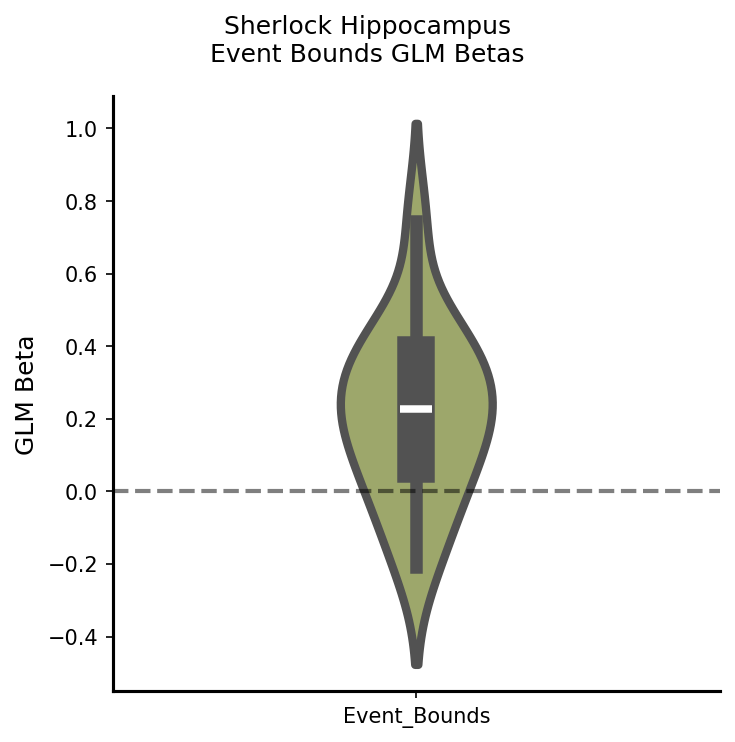

In [69]:
# combined_matrix_onsets_names =  ['Event_Bounds']
all_subs_glm_results = []
all_subs_glm_design_matrices  =[]
for sub_idx, sub_data in tqdm(enumerate(all_subs_concat_hippo_data)):

    cond_name = 'Event_Bounds'
    # Build single-condition events dataframe
    events = pd.DataFrame({
        "trial_type": cond_name,
        "onset": event_bounds_seconds-(3*tr_dur), #### Remove HRF delay for GLM
        "duration": tr_dur
    })

    # all_events.append(events)

    # combined_events = pd.concat(events, ignore_index=True)
    # Design matrix: only 1 regressor (plus drift terms)
    design_matrix = make_first_level_design_matrix(
        frame_times,
        events,
        drift_model="polynomial",
        drift_order=3,
        hrf_model="spm",
    )
    all_subs_glm_design_matrices.append(design_matrix)
    # Fit GLM: sub_data.T = shape (n_timepoints, n_rois)
    sub_mean_hippo_timeseries = np.mean(sub_data,axis=0)[None,:].T
    labels, results = run_glm(sub_mean_hippo_timeseries, design_matrix.values)

    all_subs_glm_results.append(results)
all_subs_condition_betas_hippo_GLM = np.array([subs_results[list(subs_results.keys())[0]].theta[0] for subs_results in all_subs_glm_results])[:,0]
all_subs_condition_betas = np.array([subs_results[list(subs_results.keys())[0]].theta[0] for subs_results in all_subs_glm_results])[:,0]

# Subject-wise averaged betas per condition
violin_data = all_subs_condition_betas.T
violin_data = list(violin_data)
condition_labels = []

# Plot
# plt.figure(figsize=(10, 6))

fig, axs = plt.subplots(figsize=(5, 5),dpi=dpi)
suptitle = f'{Dataset_name} Hippocampus\nEvent Bounds GLM Betas'
fig.suptitle(suptitle)
sns.violinplot(data=violin_data, inner='box', ax = axs, color=cscale[1],fill=True,width=0.25,linewidth=4)
axs.axhline(0,color='black',lw=2,ls='--',alpha=0.5)
axs.set_xticks([0],labels=[cond_name],fontsize=axis_tick_fontsize)#np.arange(len(combined_matrix_onsets_names)), combined_matrix_onsets_names)

axs.yaxis.set_tick_params(labelsize=axis_tick_fontsize)

axs.set_ylabel("GLM Beta",fontsize=axis_label_fontsize)
# axs.set_xlabel("Event Boundary",fontsize=axis_label_fontsize)

axs.spines['left'].set_linewidth(axis_edge_lw)
axs.spines['bottom'].set_linewidth(axis_edge_lw)
axs.spines['top'].set_visible(False)  # Remove top border
axs.spines['right'].set_visible(False)  # Remove right border

# axs.grid(True,zorder=1)
fig.tight_layout()

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_glm_all_bounds_hippo.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')
# Do stats and print results

res = wilcoxon(violin_data, method='asymptotic')
print(f'{Dataset_name} Wilcoxon Signed-rank Test\nZ stat:{res.zstatistic}, p-value:{res.pvalue}')

print(f'Mean Event Boundary GLM Beta Across Subjects: {np.mean(violin_data)}\nStd Event Boundary GLM Beta Across Subjects: {np.std(violin_data)}')

### 10.3 All-boundaries FIR (hippocampus)

17it [00:07,  2.13it/s]


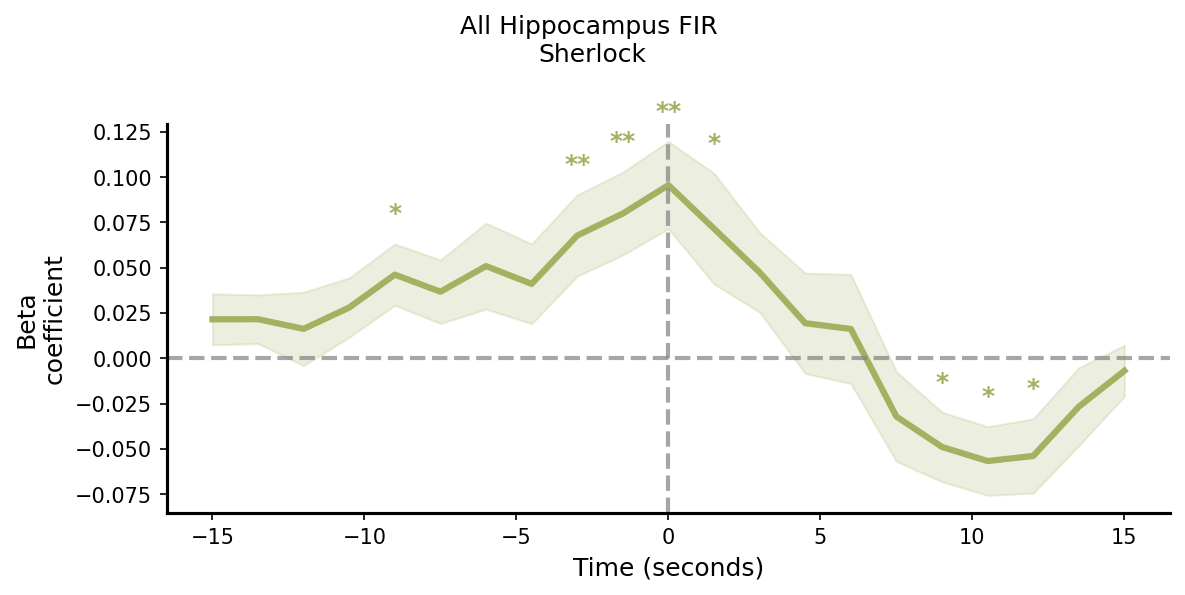

In [70]:
# combined_matrix_onsets_names =  ['Event_Bounds']
fir_duration = window_size # timepoints
all_subs_glm_results = []
all_subs_glm_design_matrices  =[]
for sub_idx, sub_data in tqdm(enumerate(all_subs_concat_hippo_data)):

    cond_name = 'Event_Bounds'
    # Build single-condition events dataframe
    events = pd.DataFrame({
        "trial_type": cond_name,
        "onset": event_bounds_seconds - (fir_duration//2)*tr_dur , ################ FIR is only forward in time. to check backwards, move bounds half the fir fduration
        "duration": tr_dur
    })

    # Design matrix: only 1 regressor (plus drift terms)
    design_matrix = make_first_level_design_matrix(
        frame_times,
        events,
        drift_model="polynomial",
        drift_order=3,
        hrf_model="fir",
        fir_delays = range(fir_duration)
    )
    all_subs_glm_design_matrices.append(design_matrix)
    # Fit GLM: sub_data.T = shape (n_timepoints, n_rois)
    sub_mean_hippo_timeseries = np.mean(sub_data,axis=0)[None,:].T
    labels, results = run_glm(sub_mean_hippo_timeseries, design_matrix.values)

    all_subs_glm_results.append(results)

EventBounds_FIR_betas = np.array([subs_results[list(subs_results.keys())[0]].theta[:fir_duration] for subs_results in all_subs_glm_results])[:,:,0]

#### HIPPOCA

fig, axs = plt.subplots(figsize=(8, 4),dpi=dpi)
suptitle = f'All Hippocampus FIR \n{Dataset_name}'
fig.suptitle(suptitle)

# Time points
time_points = np.linspace(-np.floor(fir_duration/2).astype(int), np.floor(fir_duration/2).astype(int), fir_duration)*tr_dur

# Calculate means and standard errors
EventBounds_mean = np.mean(EventBounds_FIR_betas, axis=0)
EventBounds_se = np.std(EventBounds_FIR_betas, axis=0) / np.sqrt(EventBounds_FIR_betas.shape[0])

# Plot means
line1 = axs.plot(time_points, EventBounds_mean, label=cond_name,color=cscale[1],lw=plot_line_w)

# Add standard error bands
axs.fill_between(time_points, EventBounds_mean - EventBounds_se, EventBounds_mean + EventBounds_se,color=cscale[1], alpha=0.2)

# Statistical testing
for i in range(fir_duration):
    # Test if event bounds are significantly different from 0
    t_stat_dmn, p_val_dmn = stats.ttest_1samp(EventBounds_FIR_betas[:, i], 0)

    # Significance markers for different from 0
    y_offset_eventbound = EventBounds_mean[i] + EventBounds_se[i] + 0.01

    # DMN vs 0
    if p_val_dmn < 0.001:
        axs.text(time_points[i], y_offset_eventbound, '***', ha='center', va='bottom',
                color=line1[0].get_color(), fontsize=12, fontweight='bold')
    elif p_val_dmn < 0.01:
        axs.text(time_points[i], y_offset_eventbound, '**', ha='center', va='bottom',
                color=line1[0].get_color(), fontsize=12, fontweight='bold')
    elif p_val_dmn < 0.05:
        axs.text(time_points[i], y_offset_eventbound, '*', ha='center', va='bottom',
                color=line1[0].get_color(), fontsize=12, fontweight='bold')


axs.axvline(0, color='gray', linestyle='--', alpha=0.7,lw=2)
axs.axhline(0, color='gray', linestyle='--', alpha=0.7,lw=2)

# Add legend with significance explanation
legend_elements = axs.get_legend_handles_labels()
legend_text = legend_elements[1] + [
    '* p<0.05,\n** p<0.01,\n*** p<0.001',
]
legend_handles = legend_elements[0] + [plt.Line2D([0], [0], color='none')] * 2

# axs.legend(legend_handles, legend_text, loc='upper left')#, bbox_to_anchor=(0.98, 0.95))

axs.set_xlabel('Time (seconds)',fontsize=axis_label_fontsize)
axs.set_ylabel('Beta\ncoefficient',fontsize=axis_label_fontsize)

# axs.axvline(0,ls='--',zorder=0,color='black',lw=2)
# axs.axhline(0,ls='--',zorder=0,color='black',lw=2)
axs.spines['top'].set_visible(False)  # Remove top border
axs.spines['right'].set_visible(False)  # Remove right border
axs.spines['bottom'].set_linewidth(axis_edge_lw)
axs.spines['left'].set_linewidth(axis_edge_lw)

axs.xaxis.set_tick_params(labelsize=axis_tick_fontsize)
axs.yaxis.set_tick_params(labelsize=axis_tick_fontsize)


fig.tight_layout()
if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_fir_all_bounds_hippo.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

### 10.4 Assign event boundaries to brain states

17it [00:00, 729.44it/s]


Sherlock TPN - DMN Hippo Mean
Wilcoxon Signed-rank Test
z stat:-3.621365172733304, p-value:0.0002930525201924893
Mean Event Boundary GLM Beta Across Subjects: 0.2591354683466313
Std Event Boundary GLM Beta Across Subjects: 0.0973334921486953


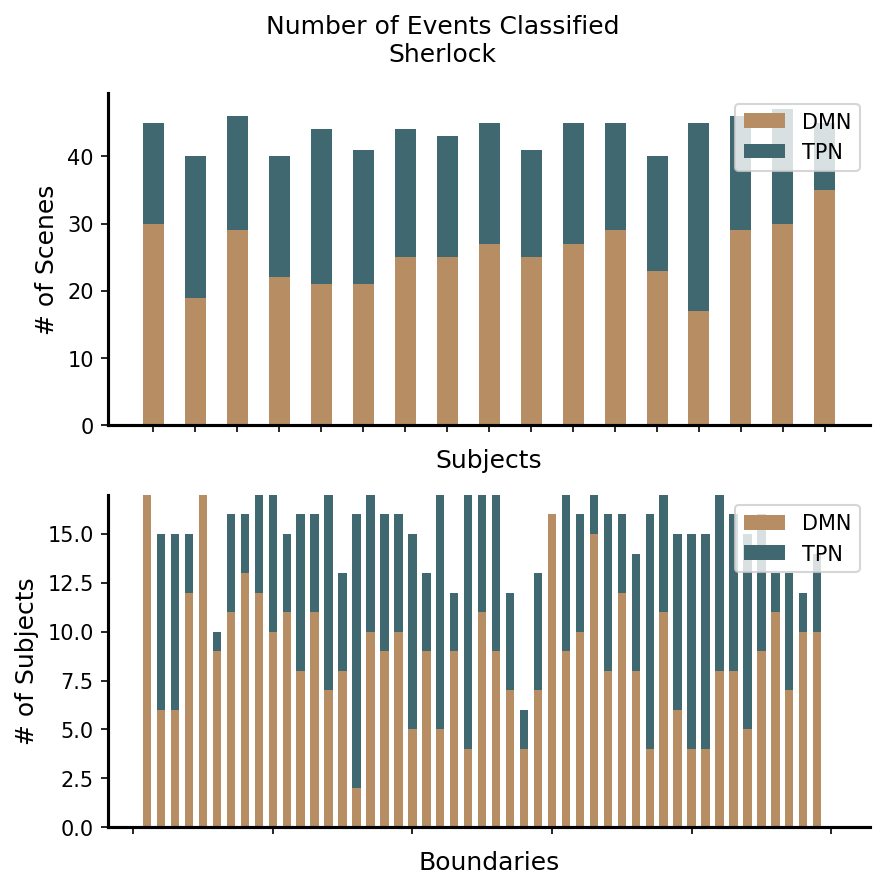

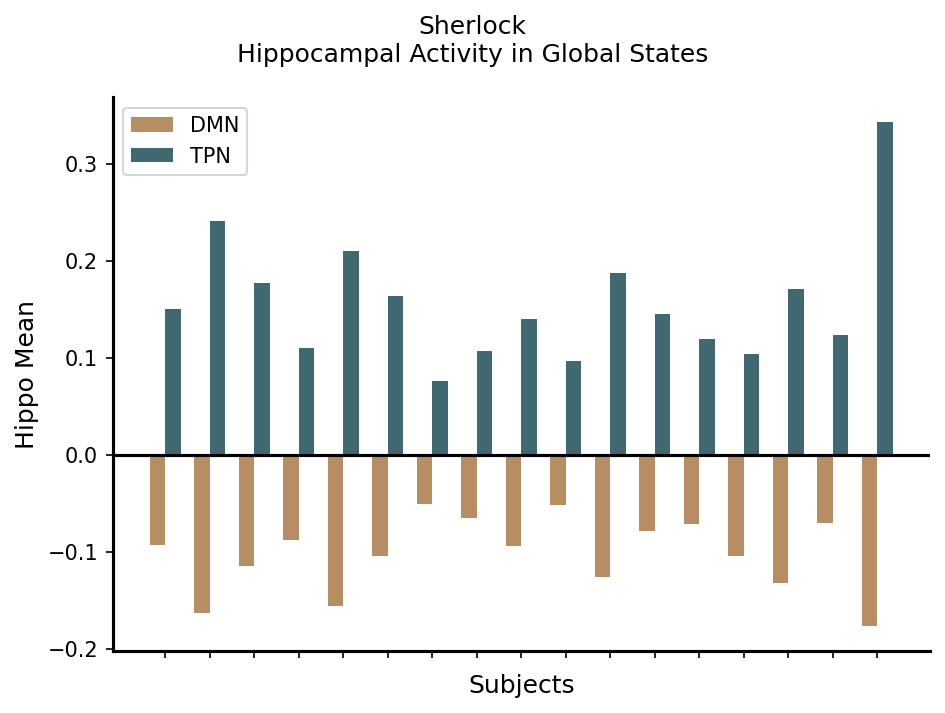

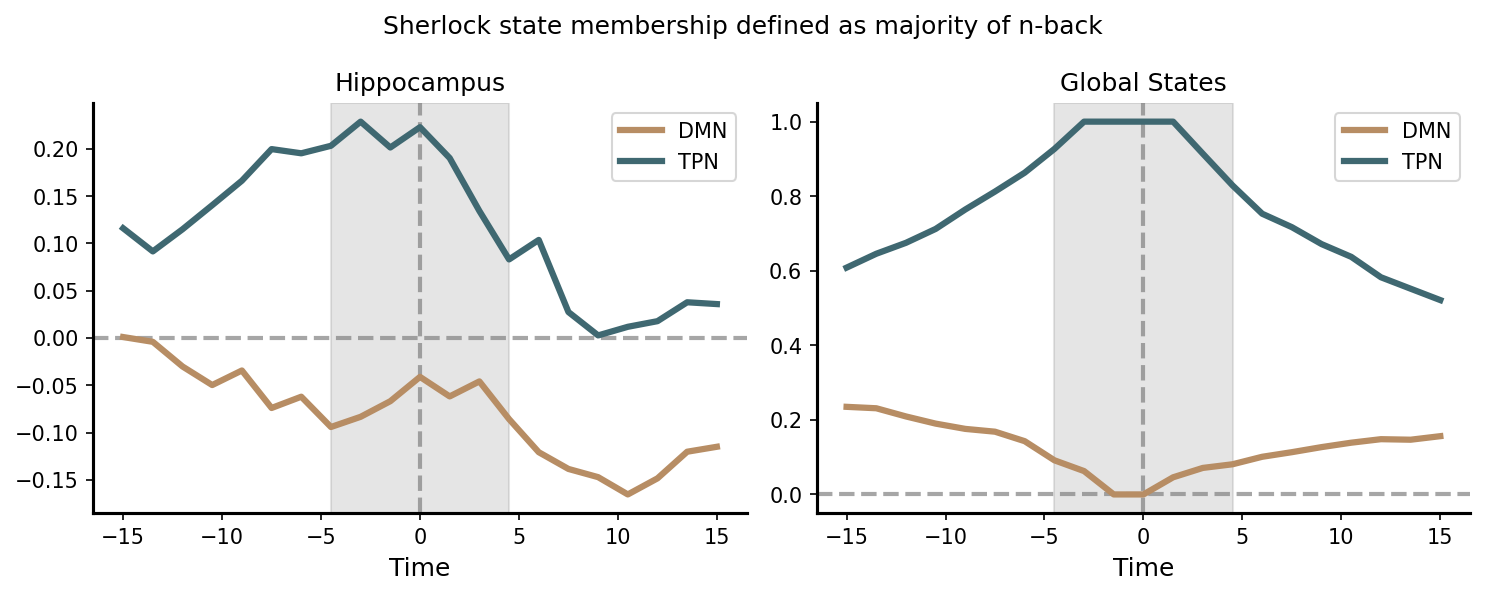

In [71]:
# threshold_num_trs_pre_bound = 5
# threshold_num_trs_post_bound = 2
# # bound_filter_threshold = 0.7
# TPN_bound_filter_threshold = 0.6
# DMN_bound_filter_threshold = 0.6

# window_size = 21
# window = np.linspace(-(window_size-1)/2,(window_size-1)/2,window_size).astype(int)
all_subs_excluded_bounds = []

all_subs_dmn_bounds_seconds = []
all_subs_tpn_bounds_seconds = []

combined_all_subs_boound_indices = []
combined_all_subs_onsets_to_test = []
# fig,axs=plt.subplots(2)
for sub_idx in range(len(sub_list)):
    sub_excluded_bounds = []
    sub_dmn_bounds_seconds = []
    sub_tpn_bounds_seconds = []
    sub_dmn_bound_inds = []
    sub_tpn_bounds_inds = []
    for bound in range(len(all_subs_event_window_hippos[sub_idx])):
        # if (event_bounds_seconds[bound]+(window[0]*tr_dur) > 0)  | (event_bounds_seconds[bound]+(window[-1]*tr_dur) < frame_times[-1]) :
        # bound_filter = np.sum(all_subs_event_window_gstates[sub_idx][bound][(len(window) // 2) - threshold_num_trs_pre_bound:(1 + len(window) // 2)]) / (threshold_num_trs_pre_bound + 1)

        bound_tr_index = event_bounds_tr[bound]
        bound_filter = np.sum(all_subs_tr_labels[sub_idx][bound_tr_index-threshold_num_trs_pre_bound:bound_tr_index+threshold_num_trs_post_bound]) / (threshold_num_trs_pre_bound + threshold_num_trs_post_bound+ 1)

        if (1- bound_filter) > DMN_bound_filter_threshold:
            sub_dmn_bounds_seconds.append(event_bounds_seconds[bound])
            sub_dmn_bound_inds.append(bound)
            # axs[0].plot(all_subs_event_window_gstates[sub_idx][bound][(len(window) // 2) - num_trs:(1 + len(window) // 2)])

        elif (bound_filter) > TPN_bound_filter_threshold:
            sub_tpn_bounds_seconds.append(event_bounds_seconds[bound])
            sub_tpn_bounds_inds.append(bound)
            # axs[1].plot(all_subs_event_window_gstates[sub_idx][bound][(len(window) // 2) - num_trs:(1 + len(window) // 2)])

        else:
          sub_excluded_bounds.append(bound)

    combined_all_subs_boound_indices.append([np.array(sub_dmn_bound_inds),np.array(sub_tpn_bounds_inds)])
    combined_all_subs_onsets_to_test.append([np.array(sub_dmn_bounds_seconds),np.array(sub_tpn_bounds_seconds)])

    all_subs_dmn_bounds_seconds.append(sub_dmn_bounds_seconds)
    all_subs_tpn_bounds_seconds.append(sub_tpn_bounds_seconds)

    all_subs_excluded_bounds.append(sub_excluded_bounds)

fig, axs = plt.subplots(2,figsize=(6,6),dpi=dpi)

suptitle = f'Number of Events Classified\n{Dataset_name}'
fig.suptitle(suptitle)

all_subs_total_classfied_event_bound_numbers = [sub_onsets[0].shape[0]+sub_onsets[1].shape[0] for sub_onsets in combined_all_subs_onsets_to_test]
all_subs_dmn_classfied_event_bound_numbers = [sub_onsets[0].shape[0] for sub_onsets in combined_all_subs_onsets_to_test]
all_subs_tpn_classfied_event_bound_numbers = [sub_onsets[1].shape[0] for sub_onsets in combined_all_subs_onsets_to_test]

barWidth = 0.5

axs[0].bar(sub_list, all_subs_dmn_classfied_event_bound_numbers, width=barWidth, color=cscale[0], label='DMN')
axs[0].bar(sub_list, all_subs_tpn_classfied_event_bound_numbers, bottom=all_subs_dmn_classfied_event_bound_numbers, width=barWidth, color=cscale[2], label='TPN')
axs[0].set_xlabel('Subjects',fontsize=axis_label_fontsize)
axs[0].set_ylabel('# of Scenes',fontsize=axis_label_fontsize)
# axs[0].axhline(event_bounds_tr.shape[0],color=cscale[3],lw=2)
# axs[0].set_xticklabels(list([sub.replace('sub-','') for sub in sub_list]), rotation=45, ha='right',fontsize=axis_label_fontsize)  # Rotate labels
axs[0].set_xticklabels([])
axs[0].xaxis.set_tick_params(labelsize=axis_tick_fontsize)
axs[0].yaxis.set_tick_params(labelsize=axis_tick_fontsize)

axs[0].spines['top'].set_visible(False)  # Remove top border
axs[0].spines['right'].set_visible(False)  # Remove right border
axs[0].spines['bottom'].set_linewidth(axis_edge_lw)
axs[0].spines['left'].set_linewidth(axis_edge_lw)


all_bounds_dmn_classified_sub_numbers = []
all_bounds_tpn_classified_sub_numbers = []

for bound in range(len(event_bounds_tr)):
    dmn_sub_counter = 0
    tpn_sub_counter = 0
    for sub_onsets in combined_all_subs_boound_indices:
        if bound in sub_onsets[0]:
            dmn_sub_counter +=1
        elif bound in sub_onsets[1]:
            tpn_sub_counter +=1
        else:
            continue
    all_bounds_dmn_classified_sub_numbers.append(dmn_sub_counter)
    all_bounds_tpn_classified_sub_numbers.append(tpn_sub_counter)

barWidth = 0.6

axs[1].bar(np.linspace(1,len(event_bounds_tr),len(event_bounds_tr)), all_bounds_dmn_classified_sub_numbers, width=barWidth, color=cscale[0], label='DMN')
axs[1].bar(np.linspace(1,len(event_bounds_tr),len(event_bounds_tr)), all_bounds_tpn_classified_sub_numbers, bottom=all_bounds_dmn_classified_sub_numbers, width=barWidth, color=cscale[2], label='TPN')
axs[1].set_xlabel('Boundaries',fontsize=axis_label_fontsize)
axs[1].set_ylabel('# of Subjects',fontsize=axis_label_fontsize)
# axs[1].axhline(len(sub_list),color=cscale[3],lw=2)

axs[1].xaxis.set_tick_params(labelsize=axis_tick_fontsize)
axs[1].yaxis.set_tick_params(labelsize=axis_tick_fontsize)
axs[1].set_xticklabels([])

axs[1].spines['top'].set_visible(False)  # Remove top border
axs[1].spines['right'].set_visible(False)  # Remove right border
axs[1].spines['bottom'].set_linewidth(axis_edge_lw)
axs[1].spines['left'].set_linewidth(axis_edge_lw)

axs[0].legend(loc='upper right')
axs[1].legend(loc='upper right')
fig.tight_layout()

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_events_classified_per_state.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')


combined_matrix_onsets_names =  ['DMN','TPN']
fir_duration = window_size # timepoints

all_subs_hippo_dmn_mean_check = []
all_subs_hippo_tpn_mean_check = []

all_subs_gstate_dmn_mean_check = []
all_subs_gstate_tpn_mean_check = []
# fig,axs=plt.subplots(2)

for sub_idx, (sub_data, sub_onsets_to_test) in tqdm(enumerate(zip(all_subs_concat_hippo_data, combined_all_subs_onsets_to_test))):

    sub_mean_hippo_timeseries = np.mean(sub_data,axis=0)[None,:].T
    sub_tr_labels = all_subs_tr_labels[sub_idx]
    subs_hippo_dmn_mean_check = []
    subs_hippo_tpn_mean_check = []

    subs_gstate_dmn_mean_check = []
    subs_gstate_tpn_mean_check = []

    sub_dmn_baseline = np.mean(sub_mean_hippo_timeseries[np.where(sub_tr_labels==0)[0]])
    sub_tpn_baseline = np.mean(sub_mean_hippo_timeseries[np.where(sub_tr_labels==1)[0]])

    for cond_count, condition_onsets in enumerate(sub_onsets_to_test):

        cond_name = combined_matrix_onsets_names[cond_count]
        sub_cond_hippo_means = []
        sub_cond_gstate_means = []
        for first_bound, cont_onset in enumerate(condition_onsets):
            if int((cont_onset//tr_dur) - (fir_duration//2)) < 0:
                continue
            onset_window_timeseries = sub_mean_hippo_timeseries[(int(cont_onset//tr_dur) - (fir_duration//2)) : (1+int(cont_onset//tr_dur) + (fir_duration//2))]
            sub_cond_hippo_means.append(onset_window_timeseries)

            onset_window_gstates = sub_tr_labels[(int(cont_onset//tr_dur) - (fir_duration//2)) : (1+int(cont_onset//tr_dur) + (fir_duration//2))]
            # print(int((cont_onset//tr_dur) - (fir_duration//2)),int(1+(cont_onset//tr_dur) + (fir_duration//2)))
            sub_cond_gstate_means.append(onset_window_gstates)

        if cond_name == 'DMN':
            subs_hippo_dmn_mean_check = sub_cond_hippo_means #- sub_dmn_baseline
            subs_gstate_dmn_mean_check = sub_cond_gstate_means
            # axs[0].plot(sub_cond_gstate_means)
        elif cond_name == 'TPN':
            subs_hippo_tpn_mean_check = sub_cond_hippo_means #- sub_tpn_baseline
            subs_gstate_tpn_mean_check = sub_cond_gstate_means
            # axs[1].plot(sub_cond_gstate_means)

    all_subs_hippo_dmn_mean_check.append(subs_hippo_dmn_mean_check)
    all_subs_hippo_tpn_mean_check.append(subs_hippo_tpn_mean_check)

    all_subs_gstate_dmn_mean_check.append(subs_gstate_dmn_mean_check)
    all_subs_gstate_tpn_mean_check.append(subs_gstate_tpn_mean_check)

all_subs_dmn_baseline = [np.mean(np.mean(sub_mean_hippo_timeseries,axis=0)[np.where(sub_tr_labels==0)]) for sub_mean_hippo_timeseries, sub_tr_labels in zip(all_subs_concat_hippo_data,all_subs_tr_labels)]
all_subs_tpn_baseline = [np.mean(np.mean(sub_mean_hippo_timeseries,axis=0)[np.where(sub_tr_labels==1)]) for sub_mean_hippo_timeseries, sub_tr_labels in zip(all_subs_concat_hippo_data,all_subs_tr_labels)]

x = np.arange(len(sub_list))
width = 0.35

fig, ax = plt.subplots(dpi=dpi)
suptitle = f'{Dataset_name}\nHippocampal Activity in Global States'
fig.suptitle(suptitle)
bars1 = ax.bar(x - width/2, all_subs_dmn_baseline, width, label='DMN',color=cscale[0])
bars2 = ax.bar(x + width/2, all_subs_tpn_baseline, width, label='TPN',color=cscale[2])

ax.set_ylabel('Hippo Mean',fontsize=axis_label_fontsize)
ax.set_xlabel('Subjects',fontsize=axis_label_fontsize)
ax.set_xticks(x)
ax.set_xticklabels([sub.replace('sub-','') for sub in sub_list], rotation=45, ha='right',fontsize=axis_label_fontsize)  # Rotate labels
ax.axhline(0,c='black')
ax.spines['top'].set_visible(False)  # Remove top border
ax.spines['right'].set_visible(False)  # Remove right border
ax.spines['bottom'].set_linewidth(axis_edge_lw)
ax.spines['left'].set_linewidth(axis_edge_lw)

ax.xaxis.set_tick_params(labelsize=axis_tick_fontsize)
ax.yaxis.set_tick_params(labelsize=axis_tick_fontsize)
ax.set_xticklabels([])

ax.legend()
plt.tight_layout()

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_hippo_mean_per_state.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

tpn_minus_dmn_hippo_baseline = np.array(all_subs_tpn_baseline) - np.array(all_subs_dmn_baseline)
res = wilcoxon(tpn_minus_dmn_hippo_baseline, method='asymptotic')
print(f'{Dataset_name} TPN - DMN Hippo Mean')
print(f'Wilcoxon Signed-rank Test\nz stat:{res.zstatistic}, p-value:{res.pvalue}')

print(f'Mean Event Boundary GLM Beta Across Subjects: {np.mean(tpn_minus_dmn_hippo_baseline)}\nStd Event Boundary GLM Beta Across Subjects: {np.std(tpn_minus_dmn_hippo_baseline)}')

dmn_hippo_mean = np.mean(np.array([np.mean(sub_check, axis=0) for sub_check in all_subs_hippo_dmn_mean_check]),axis=0)
tpn_hippo_mean = np.mean(np.array([np.mean(sub_check, axis=0) for sub_check in all_subs_hippo_tpn_mean_check]),axis=0)


dmn_gstate_mean = np.mean(np.array([np.mean(sub_check, axis=0) for sub_check in all_subs_gstate_dmn_mean_check]),axis=0)
tpn_gstate_mean = np.mean(np.array([np.mean(sub_check, axis=0) for sub_check in all_subs_gstate_tpn_mean_check]),axis=0)

fig, axs = plt.subplots(1,2,figsize=(10,4),dpi=dpi)

suptitle = f'{Dataset_name} state membership defined as majority of n-back'
fig.suptitle(suptitle)


axs[0].set_title('Hippocampus')
_ = axs[0].plot(window*tr_dur, dmn_hippo_mean,alpha=1,color=cscale[0],lw=plot_line_w,label='DMN')
_ = axs[0].plot(window*tr_dur, tpn_hippo_mean,alpha=1,color=cscale[2],lw=plot_line_w,label='TPN')
# axs[0].fill_between(np.linspace(threshold_num_trs_pre_bound,threshold_num_trs_post_bound,np.abs(threshold_num_trs_pre_bound)+threshold_num_trs_pre_bound),[1,1,1,1,1,1],color=cscale[1], alpha=0.2)
axs[0].axvspan(-threshold_num_trs_pre_bound*tr_dur, threshold_num_trs_post_bound*tr_dur, alpha=0.2,zorder=0,color='gray')#cscale[3])
# _ = axs[0].plot(window*tr_dur, tpn_hippo_mean - dmn_hippo_mean,alpha=1,color='black',lw=5, label='TPN-DMN')
axs[0].legend()
axs[0].set_xlabel('Time',fontsize=axis_label_fontsize)


axs[0].axvline(0,ls='--',zorder=0,color='gray',lw=2,alpha=0.7)
axs[0].axhline(0,ls='--',zorder=0,color='gray',lw=2,alpha=0.7)

axs[0].spines['top'].set_visible(False)  # Remove top border
axs[0].spines['right'].set_visible(False)  # Remove right border
axs[0].spines['bottom'].set_linewidth(axis_edge_lw)
axs[0].spines['left'].set_linewidth(axis_edge_lw)
axs[0].xaxis.set_tick_params(labelsize=axis_tick_fontsize)
axs[0].yaxis.set_tick_params(labelsize=axis_tick_fontsize)


axs[1].set_title('Global States')
_ = axs[1].plot(window*tr_dur, dmn_gstate_mean ,alpha=1,color=cscale[0],lw=plot_line_w,label='DMN')
_ = axs[1].plot(window*tr_dur, tpn_gstate_mean,alpha=1,color=cscale[2],lw=plot_line_w,label='TPN')
axs[1].axvspan(-threshold_num_trs_pre_bound*tr_dur, threshold_num_trs_post_bound*tr_dur, alpha=0.2,zorder=0,color='gray')#cscale[3])
# _ = axs[1].plot(window*tr_dur, tpn_gstate_mean - dmn_gstate_mean,alpha=1,color='black',lw=5, label='TPN-DMN')
axs[1].legend()
axs[1].set_xlabel('Time',fontsize=axis_label_fontsize)


axs[1].axvline(0,ls='--',zorder=0,color='gray',lw=2,alpha=0.7)
axs[1].axhline(0,ls='--',zorder=0,color='gray',lw=2,alpha=0.7)

axs[1].spines['top'].set_visible(False)  # Remove top border
axs[1].spines['right'].set_visible(False)  # Remove right border
axs[1].spines['bottom'].set_linewidth(axis_edge_lw)
axs[1].spines['left'].set_linewidth(axis_edge_lw)
axs[1].xaxis.set_tick_params(labelsize=axis_tick_fontsize)
axs[1].yaxis.set_tick_params(labelsize=axis_tick_fontsize)



fig.tight_layout()


if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_hippo_window_per_state.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

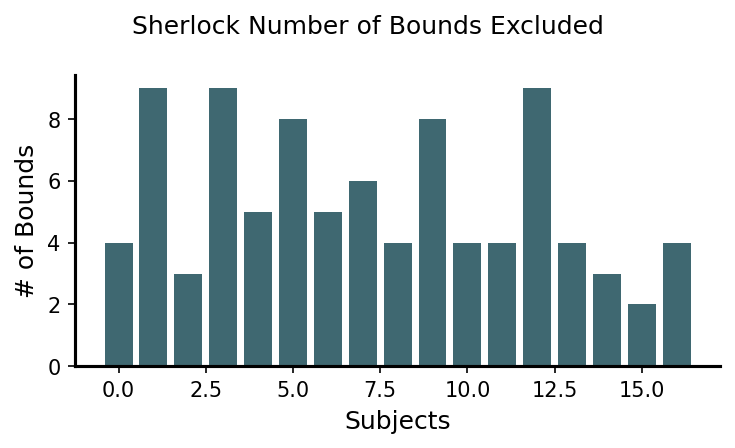

In [72]:
# Excluded Boundaries Stats

fig, axs = plt.subplots(1,figsize=(5,3),dpi=dpi)

suptitle = f'{Dataset_name} Number of Bounds Excluded'
fig.suptitle(suptitle)

axs.bar(np.arange(len(all_subs_excluded_bounds)), [len(sub_excluded) for sub_excluded in all_subs_excluded_bounds],color=cscale[2])
axs.set_xlabel('Subjects',fontsize=axis_label_fontsize)
axs.set_ylabel('# of Bounds',fontsize=axis_label_fontsize)

axs.spines['top'].set_visible(False)  # Remove top border
axs.spines['right'].set_visible(False)  # Remove right border
axs.spines['bottom'].set_linewidth(axis_edge_lw)
axs.spines['left'].set_linewidth(axis_edge_lw)
axs.xaxis.set_tick_params(labelsize=axis_tick_fontsize)
axs.yaxis.set_tick_params(labelsize=axis_tick_fontsize)



fig.tight_layout()


if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_{suptitle}.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')



### 10.5 GLM without state as regressor

15it [00:01,  8.21it/s]


StudyForrest DMN against 0
Wilcoxon Signed-rank Test
z stat:-0.6815542010964778, p-value:0.4955208830566151
Mean Event Boundary GLM Beta Across Subjects: -0.010939479764655344
Std Event Boundary GLM Beta Across Subjects: 0.06473958092305518
StudyForrest TPN against 0
Wilcoxon Signed-rank Test
z stat:-3.4077710054823886, p-value:0.0006549583433856954
Mean Event Boundary GLM Beta Across Subjects: 0.18166095146719385
Std Event Boundary GLM Beta Across Subjects: 0.10555701491616074
StudyForrest TPN against DMN
Wilcoxon Signed-rank Test
z stat:-3.2373824552082695, p-value:0.0012063162374292998
Mean Event Boundary GLM Beta Across Subjects: 0.1926004312318492
Std Event Boundary GLM Beta Across Subjects: 0.13570319987740126


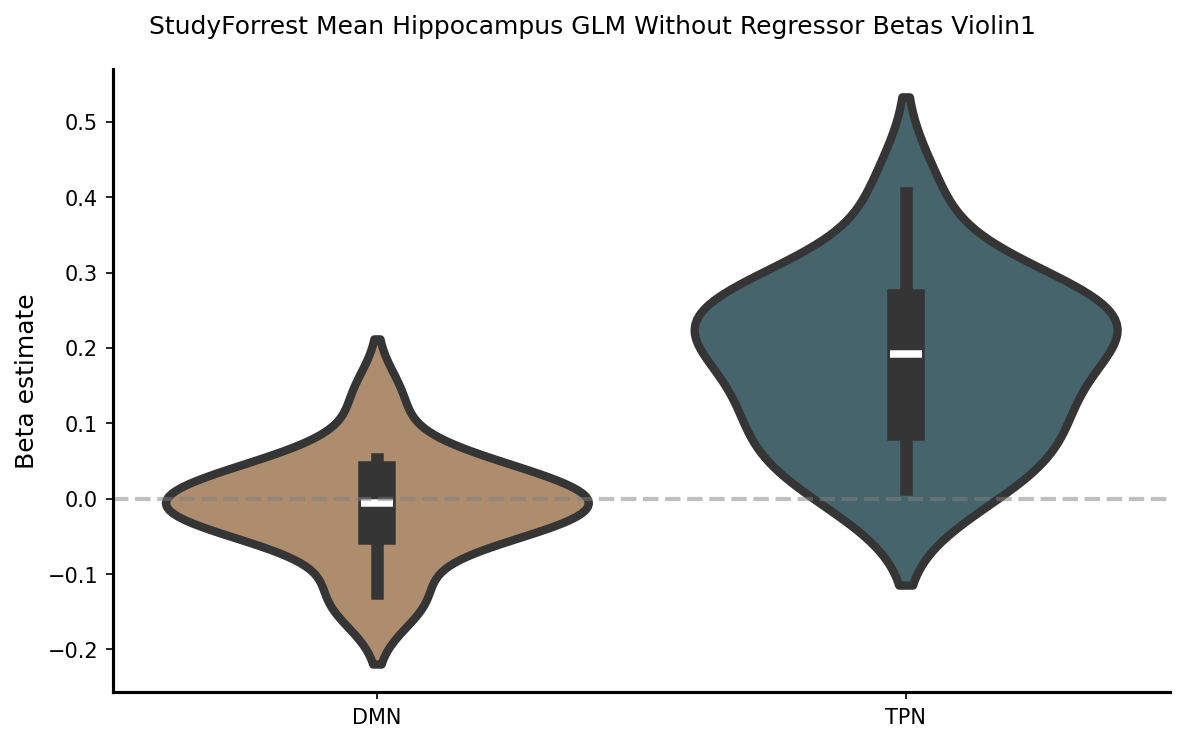

In [ ]:
combined_matrix_onsets_names =  ['DMN','TPN']
all_subs_glm_results = []
all_subs_glm_design_matrices  =[]
for sub_idx, (sub_data, sub_onsets_to_test) in tqdm(enumerate(zip(all_subs_concat_hippo_data, combined_all_subs_onsets_to_test))):
    sub_betas = []
    all_events = []
    sub_both_conds_results = []
    for cond_count, condition_onsets in enumerate(sub_onsets_to_test):

        cond_name = combined_matrix_onsets_names[cond_count]

        # Build single-condition events dataframe
        events = pd.DataFrame({
            "trial_type": cond_name,
            "onset": condition_onsets-(3*tr_dur), #### Remove HRF delay for GLM
            "duration": tr_dur
        })

        all_events.append(events)

    combined_events = pd.concat(all_events, ignore_index=True)
    # Design matrix: only 1 regressor (plus drift terms)
    design_matrix = make_first_level_design_matrix(
        frame_times,
        combined_events,
        drift_model="polynomial",
        drift_order=3,
        hrf_model="spm"
    )
    all_subs_glm_design_matrices.append(design_matrix)
    # Fit GLM: sub_data.T = shape (n_timepoints, n_rois)
    sub_mean_hippo_timeseries = np.mean(sub_data,axis=0)[None,:].T
    labels, results = run_glm(sub_mean_hippo_timeseries, design_matrix.values)

    all_subs_glm_results.append(results)

all_subs_condition_betas = np.array([subs_results[list(subs_results.keys())[0]].theta[:2] for subs_results in all_subs_glm_results])[:,:,0]

# Subject-wise averaged betas per condition
violin_data = all_subs_condition_betas.T
violin_data = list(violin_data)
condition_labels = []

# Plot
fig, axs = plt.subplots(figsize=(8, 5),dpi=dpi)
suptitle = f'{Dataset_name} Mean Hippocampus GLM Without Regressor Betas Violin1'
fig.suptitle(suptitle)
sns.violinplot(data=violin_data, inner='box', ax = axs, palette=[cscale[0],cscale[2]],fill=True,linewidth=4)
# plt.scatter(np.arange(len(onsets_to_test_names)),np.mean(violin_data,axis=1),color='black',s=44)
axs.axhline(0,color='gray',lw=2,ls='--',alpha=0.5)
axs.set_xticks(np.arange(len(combined_matrix_onsets_names)), combined_matrix_onsets_names)
axs.set_ylabel("Beta estimate",fontsize=axis_label_fontsize)
# axs.axhline(0,c='black')
axs.spines['top'].set_visible(False)  # Remove top border
axs.spines['right'].set_visible(False)  # Remove right border
axs.spines['bottom'].set_linewidth(axis_edge_lw)
axs.spines['left'].set_linewidth(axis_edge_lw)

axs.xaxis.set_tick_params(labelsize=axis_tick_fontsize)
axs.yaxis.set_tick_params(labelsize=axis_tick_fontsize)
# axs.grid(True,zorder=1)
fig.tight_layout()

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_glm_by_state_no_regressor.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

res = wilcoxon(violin_data[0], method='asymptotic')
print(f'{Dataset_name} DMN against 0')
print(f'Wilcoxon Signed-rank Test\nz stat:{res.zstatistic}, p-value:{res.pvalue}')

print(f'Mean Event Boundary GLM Beta Across Subjects: {np.mean(violin_data[0])}\nStd Event Boundary GLM Beta Across Subjects: {np.std(violin_data[0])}')

res = wilcoxon(violin_data[1], method='asymptotic')
print(f'{Dataset_name} TPN against 0')
print(f'Wilcoxon Signed-rank Test\nz stat:{res.zstatistic}, p-value:{res.pvalue}')

print(f'Mean Event Boundary GLM Beta Across Subjects: {np.mean(violin_data[1])}\nStd Event Boundary GLM Beta Across Subjects: {np.std(violin_data[1])}')

res = wilcoxon(violin_data[1] - violin_data[0], method='asymptotic')
print(f'{Dataset_name} TPN against DMN')
print(f'Wilcoxon Signed-rank Test\nz stat:{res.zstatistic}, p-value:{res.pvalue}')

print(f'Mean Event Boundary GLM Beta Across Subjects: {np.mean(violin_data[1] - violin_data[0])}\nStd Event Boundary GLM Beta Across Subjects: {np.std(violin_data[1] - violin_data[0])}')

### 10.6 FIR without state as regressor

15it [00:15,  1.05s/it]


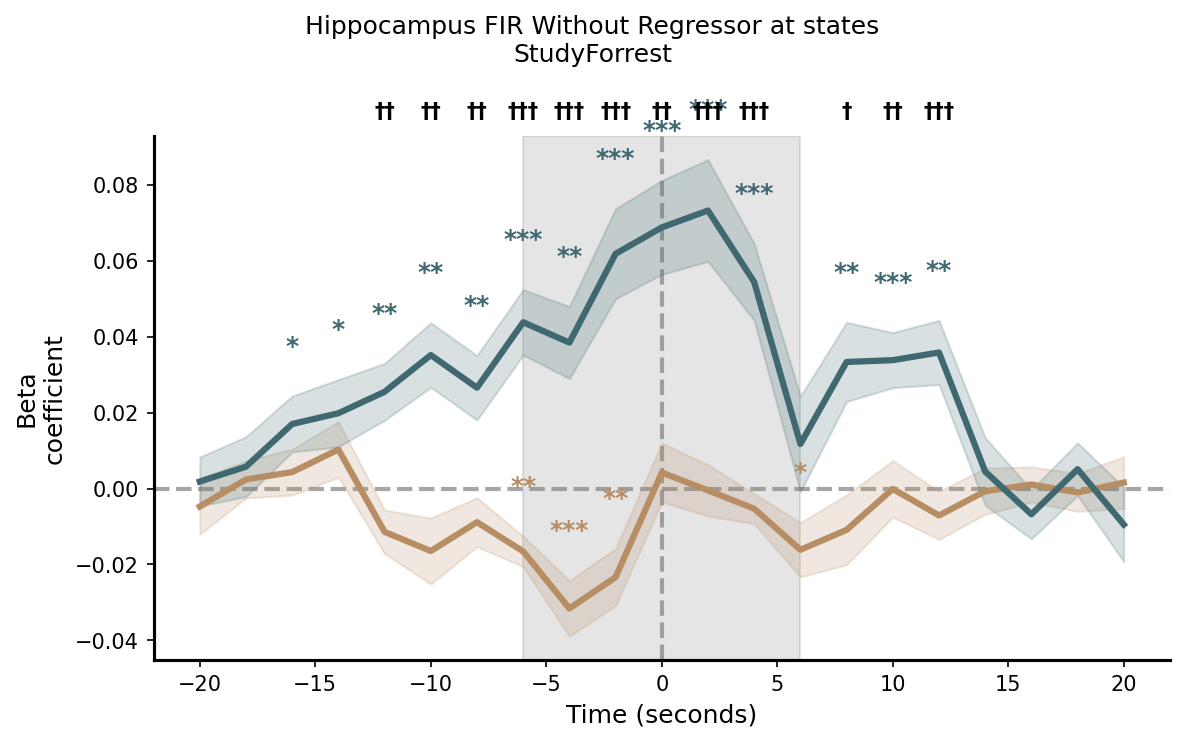

In [ ]:
combined_matrix_onsets_names =  ['DMN','TPN']
fir_duration = window_size # timepoints
all_subs_results = []
all_subs_condition_betas = []
all_sub_both_conds_results = []
all_subs_design_matrices  =[]
for sub_idx, (sub_data, sub_onsets_to_test) in tqdm(enumerate(zip(all_subs_concat_hippo_data, combined_all_subs_onsets_to_test))):
    sub_betas = []
    all_events = []
    sub_both_conds_results = []
    for cond_count, condition_onsets in enumerate(sub_onsets_to_test):
        cond_name = combined_matrix_onsets_names[cond_count]

        # Build single-condition events dataframe
        events = pd.DataFrame({
            "trial_type": cond_name,
            "onset": condition_onsets - (fir_duration//2)*tr_dur , ################ FIR is only forward in time. to check backwards, move bounds half the fir fduration
            "duration": tr_dur
        })

        all_events.append(events)
    combined_events = pd.concat(all_events, ignore_index=True)
    # Design matrix: only 1 regressor (plus drift terms)
    design_matrix = make_first_level_design_matrix(
        frame_times,
        combined_events,
        drift_model="polynomial",
        drift_order=3,
        hrf_model="fir",
        fir_delays = range(fir_duration)
    )
    all_subs_design_matrices.append(design_matrix)
    # Fit GLM: sub_data.T = shape (n_timepoints, n_rois)
    sub_mean_hippo_timeseries = np.mean(sub_data,axis=0)[None,:].T
    labels, results = run_glm(sub_mean_hippo_timeseries, design_matrix.values)
    all_subs_results.append(results)

DMN_FIR_betas = np.array([subs_results[list(subs_results.keys())[0]].theta[:fir_duration] for subs_results in all_subs_results])[:,:,0]
TPN_FIR_betas = np.array([subs_results[list(subs_results.keys())[0]].theta[fir_duration:fir_duration*2] for subs_results in all_subs_results])[:,:,0]

#### HIPPOCA

fig, axs = plt.subplots(figsize=(8, 5),dpi=dpi)
suptitle = f'Hippocampus FIR Without Regressor at states\n{Dataset_name}'
fig.suptitle(suptitle)

# Time points
time_points = np.linspace(-np.floor(fir_duration/2).astype(int), np.floor(fir_duration/2).astype(int), fir_duration)*tr_dur

# Calculate means and standard errors
DMN_mean = np.mean(DMN_FIR_betas, axis=0)
DMN_se = np.std(DMN_FIR_betas, axis=0) / np.sqrt(DMN_FIR_betas.shape[0])

TPN_mean = np.mean(TPN_FIR_betas, axis=0)
TPN_se = np.std(TPN_FIR_betas, axis=0) / np.sqrt(TPN_FIR_betas.shape[0])

# Plot means
line1 = axs.plot(time_points, DMN_mean, label=combined_matrix_onsets_names[0],color=cscale[0],lw=plot_line_w,)
line2 = axs.plot(time_points, TPN_mean, label=combined_matrix_onsets_names[1],color=cscale[2],lw=plot_line_w,)

# Add standard error bands
axs.fill_between(time_points, DMN_mean - DMN_se, DMN_mean + DMN_se,color=cscale[0], alpha=0.2)
axs.fill_between(time_points, TPN_mean - TPN_se, TPN_mean + TPN_se,color=cscale[2], alpha=0.2)

# Shade thresholding window
axs.axvspan(-threshold_num_trs_pre_bound*tr_dur, threshold_num_trs_post_bound*tr_dur, alpha=0.2,zorder=0,color='gray')#cscale[3])


# Statistical testing
for i in range(fir_duration):
    # Test if DMN is significantly different from 0
    t_stat_dmn, p_val_dmn = stats.ttest_1samp(DMN_FIR_betas[:, i], 0)

    # Test if TPN is significantly different from 0
    t_stat_tpn, p_val_tpn = stats.ttest_1samp(TPN_FIR_betas[:, i], 0)

    # Test if DMN and TPN are significantly different from each other
    t_stat_diff, p_val_diff = stats.ttest_rel(DMN_FIR_betas[:, i], TPN_FIR_betas[:, i])

    # Significance markers for different from 0
    y_offset_dmn = DMN_mean[i] + DMN_se[i] + 0.01
    y_offset_tpn = TPN_mean[i] + TPN_se[i] + 0.01

    # DMN vs 0
    if p_val_dmn < 0.001:
        axs.text(time_points[i], y_offset_dmn, '***', ha='center', va='bottom',
                color=line1[0].get_color(), fontsize=12, fontweight='bold')
    elif p_val_dmn < 0.01:
        axs.text(time_points[i], y_offset_dmn, '**', ha='center', va='bottom',
                color=line1[0].get_color(), fontsize=12, fontweight='bold')
    elif p_val_dmn < 0.05:
        axs.text(time_points[i], y_offset_dmn, '*', ha='center', va='bottom',
                color=line1[0].get_color(), fontsize=12, fontweight='bold')

    # TPN vs 0
    if p_val_tpn < 0.001:
        axs.text(time_points[i], y_offset_tpn, '***', ha='center', va='bottom',
                color=line2[0].get_color(), fontsize=12, fontweight='bold')
    elif p_val_tpn < 0.01:
        axs.text(time_points[i], y_offset_tpn, '**', ha='center', va='bottom',
                color=line2[0].get_color(), fontsize=12, fontweight='bold')
    elif p_val_tpn < 0.05:
        axs.text(time_points[i], y_offset_tpn, '*', ha='center', va='bottom',
                color=line2[0].get_color(), fontsize=12, fontweight='bold')

    # DMN vs TPN (difference between conditions)
    # Place these markers at the top of the plot
    y_max = max(max(DMN_mean + DMN_se), max(TPN_mean + TPN_se))
    y_diff_offset = y_max + 0.01

    if p_val_diff < 0.001:
        axs.text(time_points[i], y_diff_offset, '†††', ha='center', va='bottom',
                color='black', fontsize=10, fontweight='bold')
    elif p_val_diff < 0.01:
        axs.text(time_points[i], y_diff_offset, '††', ha='center', va='bottom',
                color='black', fontsize=10, fontweight='bold')
    elif p_val_diff < 0.05:
        axs.text(time_points[i], y_diff_offset, '†', ha='center', va='bottom',
                color='black', fontsize=10, fontweight='bold')


# Add legend with significance explanation
legend_elements = axs.get_legend_handles_labels()
legend_text = legend_elements[1] + [
    '* p<0.05, ** p<0.01,\n*** p<0.001,\n(vs 0)',
    '† p<0.05, †† p<0.01,\n††† p<0.001,\n(between conditions)'
]
legend_handles = legend_elements[0] + [plt.Line2D([0], [0], color='none')] * 2

# axs.legend(legend_handles, legend_text, loc='upper left')#, bbox_to_anchor=(0.98, 0.95))

axs.set_xlabel('Time (seconds)',fontsize=axis_label_fontsize)
axs.set_ylabel('Beta\ncoefficient',fontsize=axis_label_fontsize)

axs.axvline(0,ls='--',zorder=0,color='gray',alpha=0.7,lw=2)
axs.axhline(0,ls='--',zorder=0,color='gray',alpha=0.7,lw=2)

axs.spines['top'].set_visible(False)  # Remove top border
axs.spines['right'].set_visible(False)  # Remove right border
axs.spines['bottom'].set_linewidth(axis_edge_lw)
axs.spines['left'].set_linewidth(axis_edge_lw)

axs.xaxis.set_tick_params(labelsize=axis_tick_fontsize)
axs.yaxis.set_tick_params(labelsize=axis_tick_fontsize)
# legend save removed,

fig.tight_layout()
if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_fir_by_state_no_regressor.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')


### 10.7 GLM with state as regressor

The binary global-state timeseries is included as a nuisance regressor, controlling for state-level baseline differences in hippocampal activity.

15it [00:02,  5.11it/s]


StudyForrest DMN against 0
Wilcoxon Signed-rank Test
z stat:-2.1582549701388465, p-value:0.030908013652429556
Mean Event Boundary GLM Beta Across Subjects: 0.047442536157951444
Std Event Boundary GLM Beta Across Subjects: 0.05962143928973026
StudyForrest TPN against 0
Wilcoxon Signed-rank Test
z stat:-2.5558282541117916, p-value:0.010593539088689496
Mean Event Boundary GLM Beta Across Subjects: 0.0821037864898872
Std Event Boundary GLM Beta Across Subjects: 0.09126186094226704
StudyForrest TPN against DMN
Wilcoxon Signed-rank Test
z stat:-0.9655351182200101, p-value:0.3342768550264176
Mean Event Boundary GLM Beta Across Subjects: 0.034661250331935754
Std Event Boundary GLM Beta Across Subjects: 0.11201600024577683


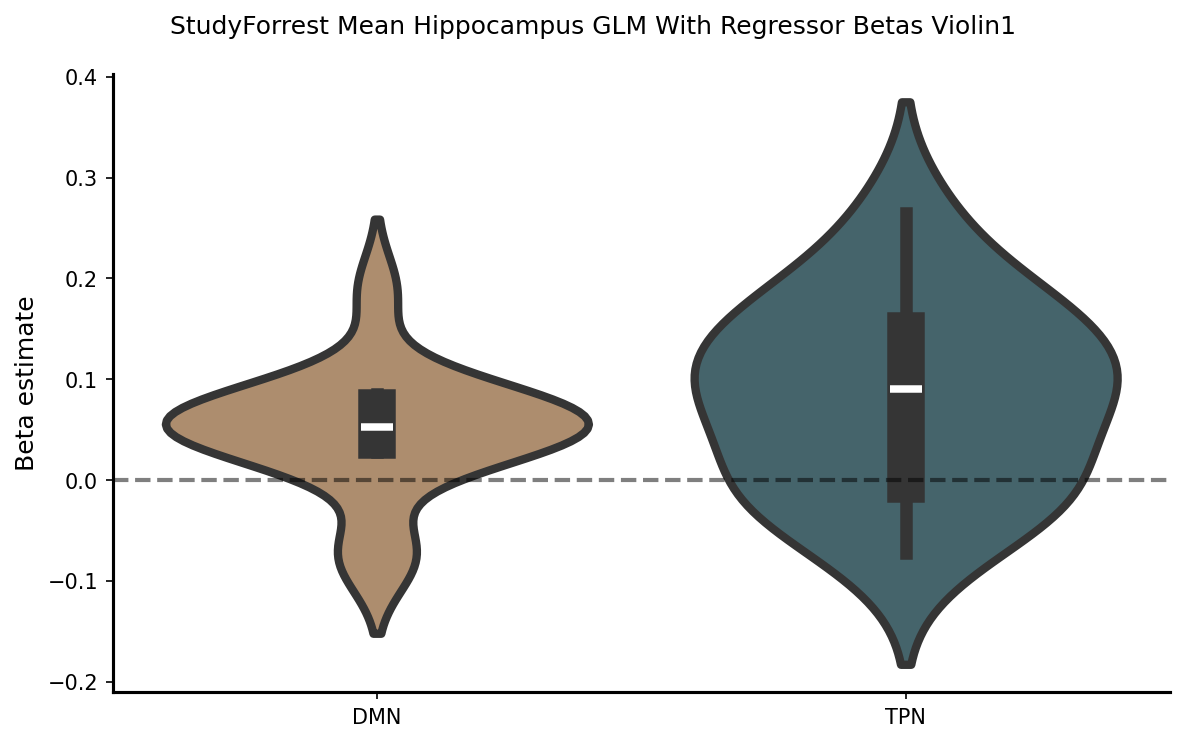

In [ ]:
combined_matrix_onsets_names =  ['DMN','TPN']
all_subs_glm_results = []
all_subs_glm_design_matrices  =[]
for sub_idx, (sub_data, sub_onsets_to_test) in tqdm(enumerate(zip(all_subs_concat_hippo_data, combined_all_subs_onsets_to_test))):
    sub_betas = []
    all_events = []
    sub_both_conds_results = []
    for cond_count, condition_onsets in enumerate(sub_onsets_to_test):

        cond_name = combined_matrix_onsets_names[cond_count]

        # Build single-condition events dataframe
        events = pd.DataFrame({
            "trial_type": cond_name,
            "onset": condition_onsets-(3*tr_dur), #### Remove HRF delay for GLM
            "duration": tr_dur
        })

        all_events.append(events)

    combined_events = pd.concat(all_events, ignore_index=True)
    # Design matrix: only 1 regressor (plus drift terms)
    design_matrix = make_first_level_design_matrix(
        frame_times,
        combined_events,
        drift_model="polynomial",
        drift_order=3,
        hrf_model="spm",
        add_regs=all_subs_tr_labels[sub_idx][None,:].T

    )
    all_subs_glm_design_matrices.append(design_matrix)
    # Fit GLM: sub_data.T = shape (n_timepoints, n_rois)
    sub_mean_hippo_timeseries = np.mean(sub_data,axis=0)[None,:].T
    labels, results = run_glm(sub_mean_hippo_timeseries, design_matrix.values)

    all_subs_glm_results.append(results)

all_subs_condition_betas = np.array([subs_results[list(subs_results.keys())[0]].theta[:2] for subs_results in all_subs_glm_results])[:,:,0]

# Subject-wise averaged betas per condition
violin_data = all_subs_condition_betas.T
violin_data = list(violin_data)
condition_labels = []

# Plot
# plt.figure(figsize=(10, 6))

fig, axs = plt.subplots(figsize=(8, 5),dpi=dpi)
suptitle = f'{Dataset_name} Mean Hippocampus GLM With Regressor Betas Violin1'
fig.suptitle(suptitle)
sns.violinplot(data=violin_data, inner='box', ax = axs, palette=[cscale[0],cscale[2]],fill=True,linewidth=4)
# plt.scatter(np.arange(len(onsets_to_test_names)),np.mean(violin_data,axis=1),color='black',s=44)
# axs.axhline(0,color='black')
axs.set_xticks(np.arange(len(combined_matrix_onsets_names)), combined_matrix_onsets_names)
axs.set_ylabel("Beta estimate",fontsize=axis_label_fontsize)
axs.axhline(0,color='black',lw=2,ls='--',alpha=0.5)
axs.spines['top'].set_visible(False)  # Remove top border
axs.spines['right'].set_visible(False)  # Remove right border
axs.spines['bottom'].set_linewidth(axis_edge_lw)
axs.spines['left'].set_linewidth(axis_edge_lw)

axs.xaxis.set_tick_params(labelsize=axis_tick_fontsize)
axs.yaxis.set_tick_params(labelsize=axis_tick_fontsize)

# axs.grid(True,zorder=1)
fig.tight_layout()

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_glm_by_state_with_regressor.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

res = wilcoxon(violin_data[0], method='asymptotic')
print(f'{Dataset_name} DMN against 0')
print(f'Wilcoxon Signed-rank Test\nz stat:{res.zstatistic}, p-value:{res.pvalue}')

print(f'Mean Event Boundary GLM Beta Across Subjects: {np.mean(violin_data[0])}\nStd Event Boundary GLM Beta Across Subjects: {np.std(violin_data[0])}')

res = wilcoxon(violin_data[1], method='asymptotic')
print(f'{Dataset_name} TPN against 0')
print(f'Wilcoxon Signed-rank Test\nz stat:{res.zstatistic}, p-value:{res.pvalue}')

print(f'Mean Event Boundary GLM Beta Across Subjects: {np.mean(violin_data[1])}\nStd Event Boundary GLM Beta Across Subjects: {np.std(violin_data[1])}')

res = wilcoxon(violin_data[1] - violin_data[0], method='asymptotic')
print(f'{Dataset_name} TPN against DMN')
print(f'Wilcoxon Signed-rank Test\nz stat:{res.zstatistic}, p-value:{res.pvalue}')

print(f'Mean Event Boundary GLM Beta Across Subjects: {np.mean(violin_data[1] - violin_data[0])}\nStd Event Boundary GLM Beta Across Subjects: {np.std(violin_data[1] - violin_data[0])}')

### 10.8 FIR with state as regressor

15it [00:16,  1.13s/it]


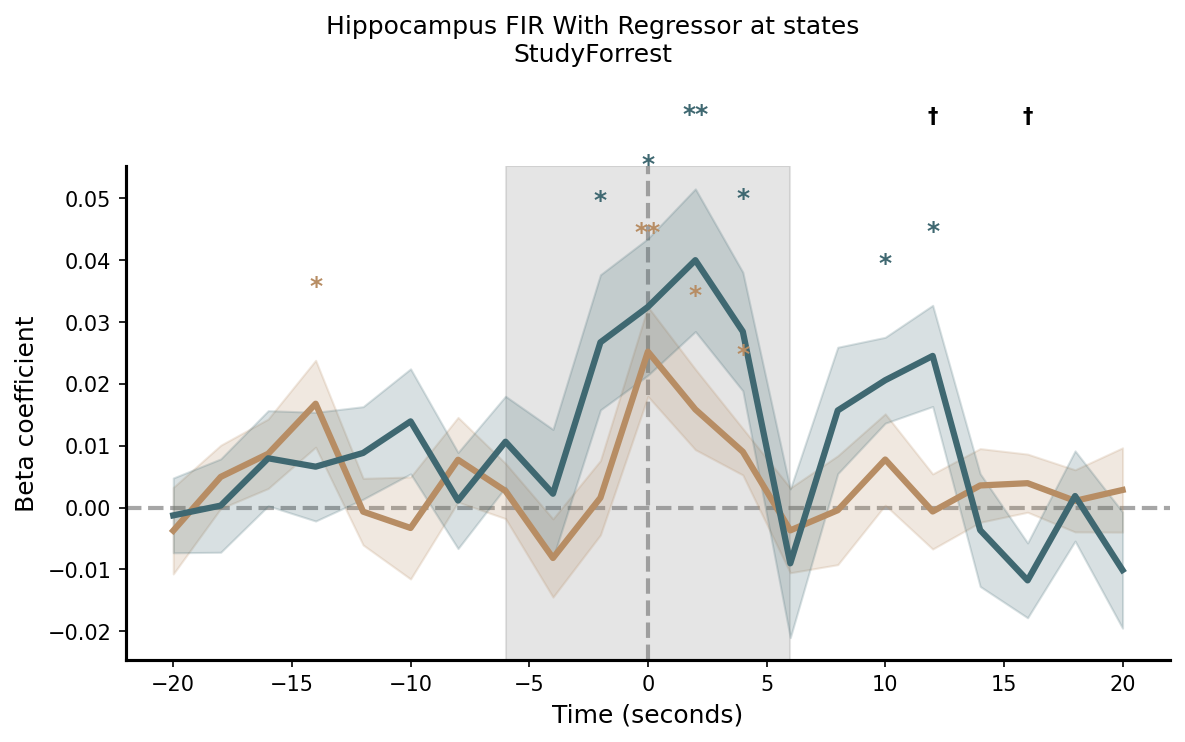

In [ ]:
combined_matrix_onsets_names =  ['DMN','TPN']
fir_duration = window_size # timepoints
all_subs_results = []
all_subs_condition_betas = []
all_sub_both_conds_results = []
all_subs_design_matrices  =[]
for sub_idx, (sub_data, sub_onsets_to_test) in tqdm(enumerate(zip(all_subs_concat_hippo_data, combined_all_subs_onsets_to_test))):
    sub_betas = []
    all_events = []
    sub_both_conds_results = []
    for cond_count, condition_onsets in enumerate(sub_onsets_to_test):
        cond_name = combined_matrix_onsets_names[cond_count]

        # Build single-condition events dataframe
        events = pd.DataFrame({
            "trial_type": cond_name,
            "onset": condition_onsets - (fir_duration//2)*tr_dur , ################ FIR is only forward in time. to check backwards, move bounds half the fir fduration
            "duration": tr_dur
        })

        all_events.append(events)
    combined_events = pd.concat(all_events, ignore_index=True)
    # Design matrix: only 1 regressor (plus drift terms)
    design_matrix = make_first_level_design_matrix(
        frame_times,
        combined_events,
        drift_model="polynomial",
        drift_order=3,
        hrf_model="fir",
        add_regs=all_subs_tr_labels[sub_idx][None,:].T,
        fir_delays = range(fir_duration)
    )
    all_subs_design_matrices.append(design_matrix)
    # Fit GLM: sub_data.T = shape (n_timepoints, n_rois)
    sub_mean_hippo_timeseries = np.mean(sub_data,axis=0)[None,:].T
    labels, results = run_glm(sub_mean_hippo_timeseries, design_matrix.values)
    all_subs_results.append(results)

DMN_FIR_betas = np.array([subs_results[list(subs_results.keys())[0]].theta[:fir_duration] for subs_results in all_subs_results])[:,:,0]
TPN_FIR_betas = np.array([subs_results[list(subs_results.keys())[0]].theta[fir_duration:fir_duration*2] for subs_results in all_subs_results])[:,:,0]

#### HIPPOCA

fig, axs = plt.subplots(figsize=(8, 5),dpi=dpi)
suptitle = f'Hippocampus FIR With Regressor at states\n{Dataset_name}'
fig.suptitle(suptitle)

# Time points
time_points = np.linspace(-np.floor(fir_duration/2).astype(int), np.floor(fir_duration/2).astype(int), fir_duration)*tr_dur

# Calculate means and standard errors
DMN_mean = np.mean(DMN_FIR_betas, axis=0)
DMN_se = np.std(DMN_FIR_betas, axis=0) / np.sqrt(DMN_FIR_betas.shape[0])

TPN_mean = np.mean(TPN_FIR_betas, axis=0)
TPN_se = np.std(TPN_FIR_betas, axis=0) / np.sqrt(TPN_FIR_betas.shape[0])

# Plot means
line1 = axs.plot(time_points, DMN_mean, label=combined_matrix_onsets_names[0],color=cscale[0],lw=plot_line_w,)
line2 = axs.plot(time_points, TPN_mean, label=combined_matrix_onsets_names[1],color=cscale[2],lw=plot_line_w,)

# Add standard error bands
axs.fill_between(time_points, DMN_mean - DMN_se, DMN_mean + DMN_se,color=cscale[0], alpha=0.2)
axs.fill_between(time_points, TPN_mean - TPN_se, TPN_mean + TPN_se,color=cscale[2], alpha=0.2)

# Shade threshold area
axs.axvspan(-threshold_num_trs_pre_bound*tr_dur, threshold_num_trs_post_bound*tr_dur, alpha=0.2,zorder=0,color='gray')#cscale[3])
# get current y-limits
ymin, ymax = ax.get_ylim()
# axs.fill_between([-threshold_num_trs_pre_bound*tr_dur,
#                  threshold_num_trs_post_bound*tr_dur],
#                 ymin, ymax,
#                 facecolor='none',
#                 hatch='///',
#                 edgecolor='black',
#                 linewidth=0,
#                 zorder=-1,
#                 alpha=0.3)


# Statistical testing
for i in range(fir_duration):
    # Test if DMN is significantly different from 0
    t_stat_dmn, p_val_dmn = stats.ttest_1samp(DMN_FIR_betas[:, i], 0)

    # Test if TPN is significantly different from 0
    t_stat_tpn, p_val_tpn = stats.ttest_1samp(TPN_FIR_betas[:, i], 0)

    # Test if DMN and TPN are significantly different from each other
    t_stat_diff, p_val_diff = stats.ttest_rel(DMN_FIR_betas[:, i], TPN_FIR_betas[:, i])

    # Significance markers for different from 0
    y_offset_dmn = DMN_mean[i] + DMN_se[i] + 0.01
    y_offset_tpn = TPN_mean[i] + TPN_se[i] + 0.01

    # DMN vs 0
    if p_val_dmn < 0.001:
        axs.text(time_points[i], y_offset_dmn, '***', ha='center', va='bottom',
                color=line1[0].get_color(), fontsize=12, fontweight='bold')
    elif p_val_dmn < 0.01:
        axs.text(time_points[i], y_offset_dmn, '**', ha='center', va='bottom',
                color=line1[0].get_color(), fontsize=12, fontweight='bold')
    elif p_val_dmn < 0.05:
        axs.text(time_points[i], y_offset_dmn, '*', ha='center', va='bottom',
                color=line1[0].get_color(), fontsize=12, fontweight='bold')

    # TPN vs 0
    if p_val_tpn < 0.001:
        axs.text(time_points[i], y_offset_tpn, '***', ha='center', va='bottom',
                color=line2[0].get_color(), fontsize=12, fontweight='bold')
    elif p_val_tpn < 0.01:
        axs.text(time_points[i], y_offset_tpn, '**', ha='center', va='bottom',
                color=line2[0].get_color(), fontsize=12, fontweight='bold')
    elif p_val_tpn < 0.05:
        axs.text(time_points[i], y_offset_tpn, '*', ha='center', va='bottom',
                color=line2[0].get_color(), fontsize=12, fontweight='bold')

    # DMN vs TPN (difference between conditions)
    # Place these markers at the top of the plot
    y_max = max(max(DMN_mean + DMN_se), max(TPN_mean + TPN_se))
    y_diff_offset = y_max + 0.01

    if p_val_diff < 0.001:
        axs.text(time_points[i], y_diff_offset, '†††', ha='center', va='bottom',
                color='black', fontsize=10, fontweight='bold')
    elif p_val_diff < 0.01:
        axs.text(time_points[i], y_diff_offset, '††', ha='center', va='bottom',
                color='black', fontsize=10, fontweight='bold')
    elif p_val_diff < 0.05:
        axs.text(time_points[i], y_diff_offset, '†', ha='center', va='bottom',
                color='black', fontsize=10, fontweight='bold')

axs.axvline(0, color='gray', linestyle='--', alpha=0.7,zorder=-1,lw=2)
axs.axhline(0, color='gray', linestyle='--', alpha=0.7,zorder=-1,lw=2)

# Add legend with significance explanation
legend_elements = axs.get_legend_handles_labels()
legend_text = legend_elements[1] + [
    '* p<0.05, ** p<0.01,\n*** p<0.001\n(vs 0)',
    '† p<0.05, †† p<0.01,\n††† p<0.001\n(between conditions)'
]
legend_handles = legend_elements[0] + [plt.Line2D([0], [0], color='none')] * 2

# axs.legend(legend_handles, legend_text, loc='upper left')#, bbox_to_anchor=(0.98, 0.95))

axs.set_xlabel('Time (seconds)',fontsize=axis_label_fontsize)
axs.set_ylabel('Beta coefficient',fontsize=axis_label_fontsize)

# axs.axvline(0,ls='--',zorder=0,color='black',alpha=0.5)
# axs.axhline(0,ls='--',zorder=0,color='black')
axs.spines['top'].set_visible(False)  # Remove top border
axs.spines['right'].set_visible(False)  # Remove right border
axs.spines['bottom'].set_linewidth(axis_edge_lw)
axs.spines['left'].set_linewidth(axis_edge_lw)

axs.xaxis.set_tick_params(labelsize=axis_tick_fontsize)
axs.yaxis.set_tick_params(labelsize=axis_tick_fontsize)
save_isolated_legend(legend_handles, legend_text,
    filename=os.path.join(FIGURE_DIR, 'fir_by_state_with_regressor_legend.png'),
    frameon=True)
fig.tight_layout()
if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_fir_by_state_with_regressor.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

### 10.9 Global states GLM

15it [00:00, 25.76it/s]


StudyForrest Global States Wilcoxon Signed-rank Test
Z stat:-3.180586271783563, p-value:0.0014697736899423487
Mean Event Boundary GLM Beta Across Subjects: 0.08252031677661824
Std Event Boundary GLM Beta Across Subjects: 0.05549167533023793


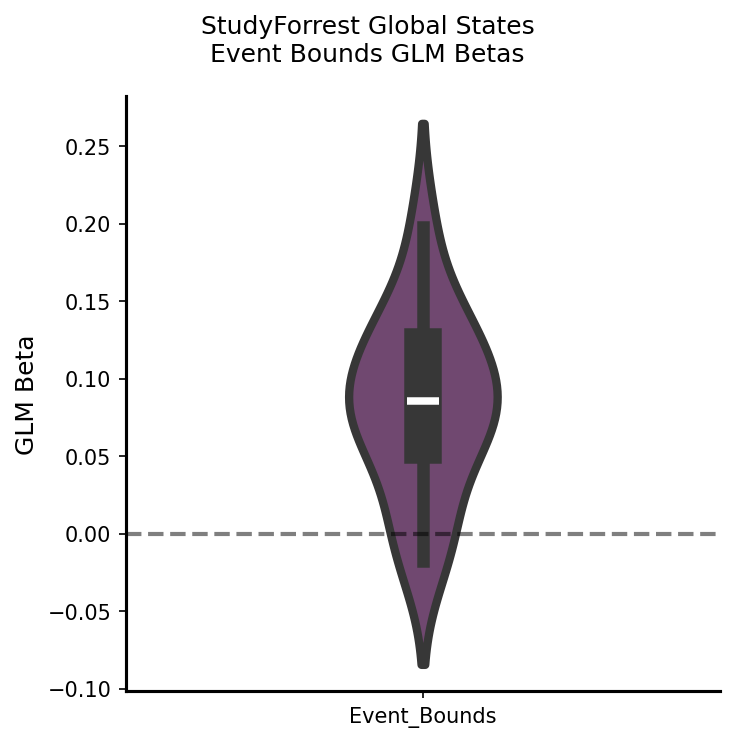

In [ ]:
# combined_matrix_onsets_names =  ['Event_Bounds']
all_subs_glm_results = []
all_subs_glm_design_matrices  =[]
for sub_idx, sub_data in tqdm(enumerate(all_subs_tr_labels)):

    cond_name = 'Event_Bounds'
    # Build single-condition events dataframe
    events = pd.DataFrame({
        "trial_type": cond_name,
        "onset": event_bounds_seconds-(3*tr_dur), #### Remove HRF delay for GLM
        "duration": tr_dur
    })

    # all_events.append(events)

    # combined_events = pd.concat(events, ignore_index=True)
    # Design matrix: only 1 regressor (plus drift terms)
    design_matrix = make_first_level_design_matrix(
        frame_times,
        events,
        drift_model="polynomial",
        drift_order=3,
        hrf_model="spm",
    )
    all_subs_glm_design_matrices.append(design_matrix)
    # Fit GLM: sub_data.T = shape (n_timepoints, n_rois)
    # sub_mean_hippo_timeseries = np.mean(sub_data,axis=0)[None,:].T
    labels, results = run_glm(sub_data[None,:].T, design_matrix.values)

    all_subs_glm_results.append(results)

all_subs_condition_betas_gstate_GLM = np.array([subs_results[list(subs_results.keys())[0]].theta[0] for subs_results in all_subs_glm_results])[:,0]

all_subs_condition_betas = np.array([subs_results[list(subs_results.keys())[0]].theta[0] for subs_results in all_subs_glm_results])[:,0]

# Subject-wise averaged betas per condition
violin_data = all_subs_condition_betas.T
violin_data = list(violin_data)
condition_labels = []

# Plot
# plt.figure(figsize=(10, 6))

fig, axs = plt.subplots(figsize=(5, 5),dpi=dpi)
suptitle = f'{Dataset_name} Global States\nEvent Bounds GLM Betas'
fig.suptitle(suptitle)
sns.violinplot(data=violin_data, inner='box', ax = axs, color=cscale[3],fill=True,width=0.25,linewidth=4)
axs.axhline(0,color='black',lw=2,ls='--',alpha=0.5)
axs.set_xticks([0],labels=[cond_name],fontsize=axis_tick_fontsize)#np.arange(len(combined_matrix_onsets_names)), combined_matrix_onsets_names)

axs.yaxis.set_tick_params(labelsize=axis_tick_fontsize)

axs.set_ylabel("GLM Beta",fontsize=axis_label_fontsize)
# axs.set_xlabel("Event Boundary",fontsize=axis_label_fontsize)

axs.spines['left'].set_linewidth(axis_edge_lw)
axs.spines['bottom'].set_linewidth(axis_edge_lw)
axs.spines['top'].set_visible(False)  # Remove top border
axs.spines['right'].set_visible(False)  # Remove right border

# axs.grid(True,zorder=1)
fig.tight_layout()

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_gstates_glm.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

# Do stats and print results

res = wilcoxon(violin_data, method='asymptotic')
print(f'{Dataset_name} Global States Wilcoxon Signed-rank Test\nZ stat:{res.zstatistic}, p-value:{res.pvalue}')

print(f'Mean Event Boundary GLM Beta Across Subjects: {np.mean(violin_data)}\nStd Event Boundary GLM Beta Across Subjects: {np.std(violin_data)}')

### 10.10 Global states FIR

15it [00:09,  1.63it/s]


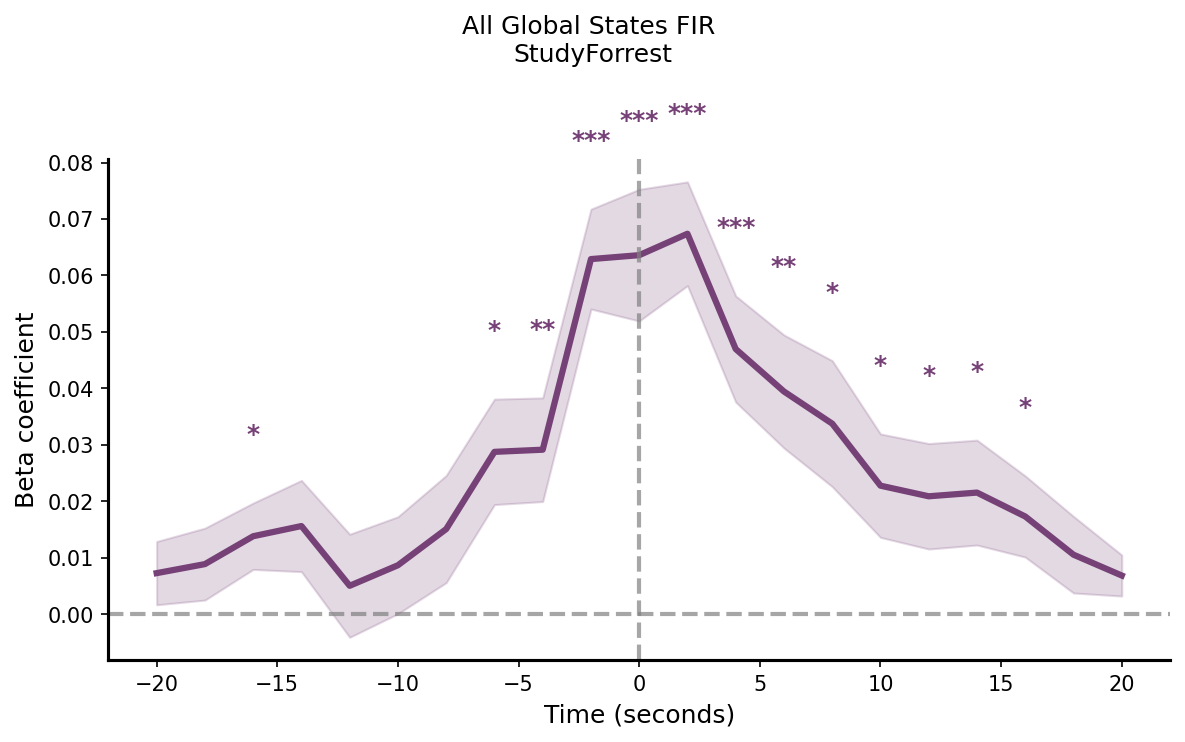

In [ ]:
# combined_matrix_onsets_names =  ['Event_Bounds']
fir_duration = window_size # timepoints
all_subs_glm_results = []
all_subs_glm_design_matrices  =[]
for sub_idx, sub_data in tqdm(enumerate(all_subs_tr_labels)):

    cond_name = 'Event_Bounds'
    # Build single-condition events dataframe
    events = pd.DataFrame({
        "trial_type": cond_name,
        "onset": event_bounds_seconds - (fir_duration//2)*tr_dur , ################ FIR is only forward in time. to check backwards, move bounds half the fir fduration
        "duration": tr_dur
    })

    # Design matrix: only 1 regressor (plus drift terms)
    design_matrix = make_first_level_design_matrix(
        frame_times,
        events,
        drift_model="polynomial",
        drift_order=3,
        hrf_model="fir",
        fir_delays = range(fir_duration)
    )
    all_subs_glm_design_matrices.append(design_matrix)
    # Fit GLM: sub_data.T = shape (n_timepoints, n_rois)
    sub_mean_hippo_timeseries = sub_data[None,:].T
    labels, results = run_glm(sub_mean_hippo_timeseries, design_matrix.values)

    all_subs_glm_results.append(results)

EventBounds_FIR_betas = np.array([subs_results[list(subs_results.keys())[0]].theta[:fir_duration] for subs_results in all_subs_glm_results])[:,:,0]

#### HIPPOCA

fig, axs = plt.subplots(figsize=(8, 5),dpi=dpi)
suptitle = f'All Global States FIR \n{Dataset_name}'
fig.suptitle(suptitle)

# Time points
time_points = np.linspace(-np.floor(fir_duration/2).astype(int), np.floor(fir_duration/2).astype(int), fir_duration)*tr_dur

# Calculate means and standard errors
EventBounds_mean = np.mean(EventBounds_FIR_betas, axis=0)
EventBounds_se = np.std(EventBounds_FIR_betas, axis=0) / np.sqrt(EventBounds_FIR_betas.shape[0])

# Plot means
line1 = axs.plot(time_points, EventBounds_mean, label=cond_name,color=cscale[3],lw=plot_line_w,)

# Add standard error bands
axs.fill_between(time_points, EventBounds_mean - EventBounds_se, EventBounds_mean + EventBounds_se,color=cscale[3], alpha=0.2)

# Statistical testing
for i in range(fir_duration):
    # Test if event bounds are significantly different from 0
    t_stat_dmn, p_val_dmn = stats.ttest_1samp(EventBounds_FIR_betas[:, i], 0)

    # Significance markers for different from 0
    y_offset_eventbound = EventBounds_mean[i] + EventBounds_se[i] + 0.01

    # DMN vs 0
    if p_val_dmn < 0.001:
        axs.text(time_points[i], y_offset_eventbound, '***', ha='center', va='bottom',
                color=line1[0].get_color(), fontsize=12, fontweight='bold')
    elif p_val_dmn < 0.01:
        axs.text(time_points[i], y_offset_eventbound, '**', ha='center', va='bottom',
                color=line1[0].get_color(), fontsize=12, fontweight='bold')
    elif p_val_dmn < 0.05:
        axs.text(time_points[i], y_offset_eventbound, '*', ha='center', va='bottom',
                color=line1[0].get_color(), fontsize=12, fontweight='bold')


axs.axvline(0, color='gray', linestyle='--', alpha=0.7,lw=2)
axs.axhline(0, color='gray', linestyle='--', alpha=0.7,lw=2)

# Add legend with significance explanation
legend_elements = axs.get_legend_handles_labels()
legend_text = legend_elements[1] + [
    '* p<0.05, ** p<0.01, *** p<0.001 (vs 0)',
]
legend_handles = legend_elements[0] + [plt.Line2D([0], [0], color='none')] * 2

# axs.legend(legend_handles, legend_text, loc='lower center')#, bbox_to_anchor=(0.98, 0.95))

axs.set_xlabel('Time (seconds)',fontsize=axis_label_fontsize)
axs.set_ylabel('Beta coefficient',fontsize=axis_label_fontsize)

# axs.axvline(0,ls='--',zorder=0,color='black')
# axs.axhline(0,ls='--',zorder=0,color='black')
axs.spines['top'].set_visible(False)  # Remove top border
axs.spines['right'].set_visible(False)  # Remove right border
axs.spines['bottom'].set_linewidth(axis_edge_lw)
axs.spines['left'].set_linewidth(axis_edge_lw)

axs.xaxis.set_tick_params(labelsize=axis_tick_fontsize)
axs.yaxis.set_tick_params(labelsize=axis_tick_fontsize)

fig.tight_layout()


if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_gstates_glm.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

## 11. Memory Analysis (Sherlock Only)

In [ ]:
if use_sherlock:
    sherlock_memory_df = pd.read_csv(
        os.path.join(DATA_ROOT, 'Sherlock_Annotations', 'Sherlock_timing_data.csv'))
    print(f'Memory data: {sherlock_memory_df.shape[0]} rows, '
          f'{sherlock_memory_df["Subject"].nunique()} subjects, '
          f'{sherlock_memory_df["Scene"].nunique()} scenes')

In [ ]:
if use_sherlock:
    all_subs_remembered_event_bounds = []
    all_subs_remembered_event_indices = []

    for count, sub_idx in enumerate(sub_list):
        sub_empty_tr_timeline = np.zeros(1976)
        sub_remembered_event_indices = np.array(sherlock_memory_df[sherlock_memory_df['Subject'] == int(sub_idx)]['Scene'])
        # print(sub_remembered_event_onsets)
        sub_empty_tr_timeline[sub_remembered_event_indices] = 1

        all_subs_remembered_event_bounds.append(sub_empty_tr_timeline)
        all_subs_remembered_event_indices.append(sub_remembered_event_indices)

In [ ]:
if use_sherlock:

    fig,axs = plt.subplots(dpi=dpi)
    suptitle = f'{Dataset_name} Memory Scores'
    fig.suptitle(suptitle)
    axs.bar([sub.replace('sub-','') for sub in sub_list], [np.where(subs_remembered_event_bounds!=0)[0].shape[0] for subs_remembered_event_bounds in all_subs_remembered_event_bounds],color=cscale[3])
    axs.set_xlabel('Subjects',fontsize=axis_label_fontsize)
    axs.set_ylabel('# of Scenes\nRemembered',fontsize=axis_label_fontsize)
    axs.spines['top'].set_visible(False)  # Remove top border
    axs.spines['right'].set_visible(False)  # Remove right border
    axs.spines['bottom'].set_linewidth(axis_edge_lw)
    axs.spines['left'].set_linewidth(axis_edge_lw)

    axs.xaxis.set_tick_params(labelsize=axis_tick_fontsize)
    axs.yaxis.set_tick_params(labelsize=axis_tick_fontsize)
    axs.set_xticklabels([sub.replace('sub-','') for sub in sub_list], rotation=60, ha='right',fontsize=axis_tick_fontsize)  # Rotate labels

    fig.tight_layout()

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_memory_scores.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
if use_sherlock:
    subjects_per_scene = sherlock_memory_df.groupby('Scene')['Subject'].nunique()
    fig,axs = plt.subplots(dpi=dpi)
    suptitle = f'{Dataset_name} Memory Scores per Scene'
    fig.suptitle(suptitle)
    axs.bar(np.linspace(1,subjects_per_scene.shape[0],subjects_per_scene.shape[0]).astype(int), subjects_per_scene ,color=cscale[3])
    axs.set_xlabel('Scenes',fontsize=axis_label_fontsize)
    axs.set_ylabel('# of Subjects\nRemembered',fontsize=axis_label_fontsize)
    axs.spines['top'].set_visible(False)  # Remove top border
    axs.spines['right'].set_visible(False)  # Remove right border
    axs.spines['bottom'].set_linewidth(axis_edge_lw)
    axs.spines['left'].set_linewidth(axis_edge_lw)

    axs.xaxis.set_tick_params(labelsize=axis_tick_fontsize)
    axs.yaxis.set_tick_params(labelsize=axis_tick_fontsize)

    fig.tight_layout()

    # if save_figures:

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_memory_scores_per_scene.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

### 11.1 State proportion and memory

In [ ]:
# sub_tr_labels = all_subs_tr_labels[0]
if use_sherlock:

    all_subs_dmn_props = []
    all_subs_tpn_props = []

    for sub_tr_labels in all_subs_tr_labels:
        sub_dmn_prob = sub_tr_labels[sub_tr_labels==0].shape[0] / sub_tr_labels.shape[0]
        sub_tpn_prob = sub_tr_labels[sub_tr_labels==1].shape[0] / sub_tr_labels.shape[0]

        all_subs_dmn_props.append(sub_dmn_prob)
        all_subs_tpn_props.append(sub_tpn_prob)

    all_subs_dmn_props = np.array(all_subs_dmn_props)
    all_subs_tpn_props = np.array(all_subs_tpn_props)

In [ ]:
if use_sherlock:
    fig, axs = plt.subplots(1,2,figsize=(8,4),dpi=dpi)
    suptitle = 'Subject-wise Overall (not at event bounds) Analysis'
    fig.suptitle(suptitle)
    sub_dmn_proportions = [combined_all_subs_boound_indices[sub_idx][0].shape[0] / event_bounds_tr.shape[0] for sub_idx in range(len(sub_list))]
    sub_tpn_proportions = [combined_all_subs_boound_indices[sub_idx][1].shape[0] / event_bounds_tr.shape[0] for sub_idx in range(len(sub_list))]
    # memory scores are number of remembered scenes divided by number of all scenes
    sub_memory_scores = [sum(sub_remembered_event_bounds) for sub_remembered_event_bounds in all_subs_remembered_event_bounds]

    axs[0].scatter(sub_memory_scores,all_subs_dmn_props,c=cscale[0],s=scatter_s)
    slope, intercept, r_value, p_value, std_err = stats.linregress(sub_memory_scores, all_subs_dmn_props)
    axs[0].axline([20, intercept + slope * 20],slope=slope,color='black',label='Least Squares Fit',ls='-')#,zorder=0)
    axs[0].set_title(f'Prop in DMN and Memory\n Pearson R: {np.round(r_value,4)}\n p:{np.round(p_value,4)}')
    axs[0].set_xlabel('Memory Score',fontsize=axis_label_fontsize)
    axs[0].set_ylabel('DMN Prop',fontsize=axis_label_fontsize)

    axs[0].spines['top'].set_visible(False)  # Remove top border
    axs[0].spines['right'].set_visible(False)  # Remove right border
    axs[0].spines['bottom'].set_linewidth(axis_edge_lw)
    axs[0].spines['left'].set_linewidth(axis_edge_lw)

    axs[0].xaxis.set_tick_params(labelsize=axis_tick_fontsize)
    axs[0].yaxis.set_tick_params(labelsize=axis_tick_fontsize)

    axs[1].scatter(sub_memory_scores,all_subs_tpn_props,c=cscale[2],s=scatter_s)
    slope, intercept, r_value, p_value, std_err = stats.linregress(sub_memory_scores, all_subs_tpn_props)
    axs[1].axline([20, intercept + slope * 20],slope=slope,color='black',label='Least Squares Fit',ls='-')#,zorder=0)
    axs[1].set_title(f'Prop in TPN and Memory\n Pearson R: {np.round(r_value,4)}\n p:{np.round(p_value,4)}')
    axs[1].set_xlabel('Memory Score',fontsize=axis_label_fontsize)
    axs[1].set_ylabel('TPN Prop',fontsize=axis_label_fontsize)

    axs[1].spines['top'].set_visible(False)  # Remove top border
    axs[1].spines['right'].set_visible(False)  # Remove right border
    axs[1].spines['bottom'].set_linewidth(axis_edge_lw)
    axs[1].spines['left'].set_linewidth(axis_edge_lw)

    axs[1].xaxis.set_tick_params(labelsize=axis_tick_fontsize)
    axs[1].yaxis.set_tick_params(labelsize=axis_tick_fontsize)

    bar_width = 0.3
    # axs[2].bar(sub_list,np.array(sub_dmn_proportions)/np.array(sub_tpn_proportions))
    y1 = np.array(sub_dmn_proportions)/np.array(sub_tpn_proportions)
    y2 = np.array(sub_memory_scores)/50

    x = np.arange(len(sub_list))  # numeric positions for each label
    width = 0.35

    # axs[2].bar(x - width/2, y1, width, label='Set 1')
    # axs[2].bar(x + width/2, y2, width, label='Set 2')
    # axs[2].scatter(y1,y2)
    # slope, intercept, r_value, p_value, std_err = stats.linregress(y1, y2)
    # axs[2].axline([0, intercept + slope * 0],slope=slope,color='black',label='Least Squares Fit',ls='-')#,zorder=0)
    # axs[2].set_title(f'Prop in DMN/TPN and Memory\nPearson R: {np.round(r_value,4)}\n p:{np.round(p_value,4)}')
    # axs[2].set_xlabel('Memory Score')
    # axs[2].set_ylabel('DMN/TPN')
    # axs[2].set_xticks(x, sub_list)

    fig.tight_layout()

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_state_memory_scatter_with_outlier.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
#### WITHOUT OUTLIER
if use_sherlock:
    fig, axs = plt.subplots(1,2,figsize=(8,4),dpi=dpi)
    suptitle = 'Subject-wise Overall (not at event bounds) Analysis WithoutOutlier'
    fig.suptitle(suptitle)
    sub_dmn_proportions = np.array([combined_all_subs_boound_indices[sub_idx][0].shape[0] / event_bounds_tr.shape[0] for sub_idx in range(len(sub_list))])
    sub_tpn_proportions = np.array([combined_all_subs_boound_indices[sub_idx][1].shape[0] / event_bounds_tr.shape[0] for sub_idx in range(len(sub_list))])
    # memory scores are number of remembered scenes divided by number of all scenes
    sub_memory_scores = np.array([sum(sub_remembered_event_bounds) for sub_remembered_event_bounds in all_subs_remembered_event_bounds])


    outlier_free_sub_dmn_proportions = all_subs_dmn_props[all_subs_dmn_props>0.52]
    outlier_free_sub_tpn_proportions = all_subs_tpn_props[all_subs_dmn_props>0.52]
    outlier_free_sub_memory_scores = sub_memory_scores[all_subs_dmn_props>0.52]

    # plot outlier in red
    axs[0].scatter(sub_memory_scores[all_subs_dmn_props<0.52],all_subs_dmn_props[all_subs_dmn_props<0.52],c='red',s=scatter_s)#cscale[3])
    axs[1].scatter(sub_memory_scores[all_subs_dmn_props<0.52],all_subs_tpn_props[all_subs_dmn_props<0.52],c='red',s=scatter_s)#cscale[3])


    axs[0].scatter(outlier_free_sub_memory_scores,outlier_free_sub_dmn_proportions,c=cscale[0],s=scatter_s)
    slope, intercept, r_value, p_value, std_err = stats.linregress(outlier_free_sub_memory_scores, outlier_free_sub_dmn_proportions)
    axs[0].axline([20, intercept + slope * 20],slope=slope,color='black',label='Least Squares Fit',ls='-')#,zorder=0)
    axs[0].set_title(f'Prop in DMN and Memory\n Pearson R: {np.round(r_value,4)}\n p:{np.round(p_value,4)}')
    axs[0].set_xlabel('Memory Score',fontsize=axis_label_fontsize)
    axs[0].set_ylabel('DMN Prop',fontsize=axis_label_fontsize)

    axs[0].spines['top'].set_visible(False)  # Remove top border
    axs[0].spines['right'].set_visible(False)  # Remove right border
    axs[0].spines['bottom'].set_linewidth(axis_edge_lw)
    axs[0].spines['left'].set_linewidth(axis_edge_lw)

    axs[0].xaxis.set_tick_params(labelsize=axis_tick_fontsize)
    axs[0].yaxis.set_tick_params(labelsize=axis_tick_fontsize)

    axs[1].scatter(outlier_free_sub_memory_scores,outlier_free_sub_tpn_proportions,c=cscale[2],s=scatter_s)
    slope, intercept, r_value, p_value, std_err = stats.linregress(outlier_free_sub_memory_scores, outlier_free_sub_tpn_proportions)
    axs[1].axline([20, intercept + slope * 20],slope=slope,color='black',label='Least Squares Fit',ls='-')#,zorder=0)
    axs[1].set_title(f'Prop in TPN and Memory\n Pearson R: {np.round(r_value,4)}\n p:{np.round(p_value,4)}')
    axs[1].set_xlabel('Memory Score',fontsize=axis_label_fontsize)
    axs[1].set_ylabel('TPN Prop',fontsize=axis_label_fontsize)

    axs[1].spines['top'].set_visible(False)  # Remove top border
    axs[1].spines['right'].set_visible(False)  # Remove right border
    axs[1].spines['bottom'].set_linewidth(axis_edge_lw)
    axs[1].spines['left'].set_linewidth(axis_edge_lw)

    axs[1].xaxis.set_tick_params(labelsize=axis_tick_fontsize)
    axs[1].yaxis.set_tick_params(labelsize=axis_tick_fontsize)

    bar_width = 0.3
    # axs[2].bar(sub_list,np.array(sub_dmn_proportions)/np.array(sub_tpn_proportions))
    y1 = np.array(outlier_free_sub_dmn_proportions)/np.array(outlier_free_sub_tpn_proportions)
    y2 = np.array(outlier_free_sub_memory_scores)/50

    x = np.arange(len(sub_list))  # numeric positions for each label
    width = 0.35

    # axs[2].bar(x - width/2, y1, width, label='Set 1')
    # axs[2].bar(x + width/2, y2, width, label='Set 2')
    # axs[2].scatter(y1,y2)
    # slope, intercept, r_value, p_value, std_err = stats.linregress(y1, y2)
    # axs[2].axline([0, intercept + slope * 0],slope=slope,color='black',label='Least Squares Fit',ls='-')#,zorder=0)
    # axs[2].set_title(f'Prop in DMN/TPN and Memory\nPearson R: {np.round(r_value,4)}\n p:{np.round(p_value,4)}')
    # axs[2].set_xlabel('Memory Score')
    # axs[2].set_ylabel('DMN/TPN')
    # axs[2].set_xticks(x, sub_list)

    fig.tight_layout()

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_state_memory_scatter_without_outlier.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
if use_sherlock:

    fig,axs = plt.subplots(figsize=(4,4),dpi=dpi)
    axs.scatter(sub_memory_scores,all_subs_gstate_at_event,c=cscale[2],s=scatter_s)
    slope, intercept, r_value, p_value, std_err = stats.linregress(sub_memory_scores, all_subs_gstate_at_event)
    axs.axline([20, intercept + slope * 20],slope=slope,color='black',label='Least Squares Fit',ls='-')#,zorder=0)
    axs.set_title(f'Prop more in TPN at Bound and Memory\n Pearson R: {np.round(r_value,4)}\n p:{np.round(p_value,4)}')
    axs.set_xlabel('Memory Score',fontsize=axis_label_fontsize)
    axs.set_ylabel('TPN Prop at Event Bounds',fontsize=axis_label_fontsize)

    axs.spines['top'].set_visible(False)  # Remove top border
    axs.spines['right'].set_visible(False)  # Remove right border
    axs.spines['bottom'].set_linewidth(axis_edge_lw)
    axs.spines['left'].set_linewidth(axis_edge_lw)

    axs.xaxis.set_tick_params(labelsize=axis_tick_fontsize)
    axs.yaxis.set_tick_params(labelsize=axis_tick_fontsize)

    suptitle = f'Memory and Global States at Event {Dataset_name}'
    fig.suptitle(suptitle)
    fig.tight_layout()
    # if save_figures:

if save_figures:
    plt.savefig(os.path.join(FIGURE_DIR, 'memory_gstates_scatter.png'),
                transparent=True, dpi=dpi, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
if use_sherlock:
#  all_subs_hippo_at_event all_subs_condition_betas_hippo_GLM violin_data[0] all_subs_condition_betas_hippo_GLM
    fig,axs = plt.subplots(figsize=(4,4),dpi=dpi)

    axs.scatter(sub_memory_scores,all_subs_condition_betas_hippo_GLM,s=scatter_s,c=cscale[1])
    slope, intercept, r_value, p_value, std_err = stats.linregress(sub_memory_scores, all_subs_condition_betas_hippo_GLM)
    axs.axline([20, intercept + slope * 20],slope=slope,color='black',label='Least Squares Fit',ls='-')#,zorder=0)
    axs.set_title(f'Hippo Activity and Memory\n Pearson R: {np.round(r_value,4)}\n p:{np.round(p_value,4)}')
    axs.set_xlabel('Memory Score',fontsize=axis_label_fontsize)
    axs.set_ylabel('Hippo at Event Bounds',fontsize=axis_label_fontsize)

    axs.spines['top'].set_visible(False)  # Remove top border
    axs.spines['right'].set_visible(False)  # Remove right border
    axs.spines['bottom'].set_linewidth(axis_edge_lw)
    axs.spines['left'].set_linewidth(axis_edge_lw)

    axs.xaxis.set_tick_params(labelsize=axis_tick_fontsize)
    axs.yaxis.set_tick_params(labelsize=axis_tick_fontsize)

    suptitle = f'Memory and Hippo GLM beta at Event {Dataset_name}'
    fig.suptitle(suptitle)
    fig.tight_layout()

    if save_figures:
        plt.savefig(os.path.join(FIGURE_DIR, f'{Dataset_name}_memory_hippo_glm_scatter.png'),
                    transparent=True, dpi=dpi, bbox_inches='tight')

### 11.2 High vs low memory subgroup FIR

In [ ]:
if use_sherlock:

    high_memory_sub_indices = np.where(sub_memory_scores>np.median(sub_memory_scores))[0]
    low_memory_sub_indices = np.where(sub_memory_scores<np.median(sub_memory_scores))[0]

In [ ]:
if use_sherlock:

    window = np.linspace(-(window_size-1)/2,(window_size-1)/2,window_size).astype(int)

    all_subs_event_window_hippos = []
    all_subs_event_window_gstates = []
    for sub_idx in high_memory_sub_indices:
        sub_event_window_hippos = []
        sub_event_window_gstates = []
        for bound in event_bounds_tr:
            if (bound >= int(window_size/2)) and (bound+int(window_size/2))<(all_subs_concat_hippo_data[sub_idx].shape[1]):
                bound_window = bound+window
                bound_window_hippo = all_subs_concat_hippo_data[sub_idx][:,bound_window]
                mean_bound_window_hippo = np.mean(bound_window_hippo,axis=0)
                sub_event_window_hippos.append(mean_bound_window_hippo)

                bound_window_gstates = all_subs_tr_labels[sub_idx][bound_window]
                sub_event_window_gstates.append(bound_window_gstates)

        all_subs_event_window_hippos.append(sub_event_window_hippos)
        all_subs_event_window_gstates.append(sub_event_window_gstates)

    fig, axs = plt.subplots(2,1,figsize=(7,5),sharex=True,dpi=dpi)
    suptitle = f'Memory Group Average Event Bounds Response in {Dataset_name}'
    fig.suptitle(suptitle)

    axs[0].plot(window*tr_dur,np.mean(np.mean(all_subs_event_window_hippos,axis=0),axis=0),alpha=1,color=cscale[2],lw=5,label='high memory')
    all_subs_event_window_hippos_mean = np.mean(all_subs_event_window_hippos, axis=0)
    all_subs_event_window_hippos_se = np.std(all_subs_event_window_hippos_mean, axis=0) / np.sqrt(np.array(all_subs_event_window_hippos).shape[0])
    axs[0].fill_between(window*tr_dur,(np.mean(all_subs_event_window_hippos_mean,axis=0) - all_subs_event_window_hippos_se), (np.mean(all_subs_event_window_hippos_mean,axis=0) + all_subs_event_window_hippos_se),color=cscale[2],alpha=0.2)

    axs[0].set_ylabel('Hippo Activity')
    axs[0].axvline(0,ls='--',zorder=0,color='black')
    axs[0].axhline(0,ls='--',zorder=0,color='black')
    axs[0].spines['top'].set_visible(False)  # Remove top border
    axs[0].spines['right'].set_visible(False)  # Remove right border

    # By demeaning, 0 is baseline for each subject, and not 50/50
    # Am unsure about demeaning!!!!!
    demeaned_all_subs_event_window_gstates = (np.array(all_subs_event_window_gstates) - np.mean(np.array(all_subs_event_window_gstates),axis=(1,2))[:,None,None])

    demeaned_all_subs_event_window_gstates_mean = np.mean(demeaned_all_subs_event_window_gstates, axis=0)
    demeaned_all_subs_event_window_gstates_se = np.std(demeaned_all_subs_event_window_gstates_mean, axis=0) / np.sqrt(demeaned_all_subs_event_window_gstates.shape[0])


    axs[1].plot(window*tr_dur,np.mean(np.mean(demeaned_all_subs_event_window_gstates,axis=0),axis=0),alpha=1,color=cscale[2],lw=5,label='high memory')
    axs[1].fill_between(window*tr_dur,(np.mean(demeaned_all_subs_event_window_gstates_mean,axis=0) - demeaned_all_subs_event_window_gstates_se), (np.mean(demeaned_all_subs_event_window_gstates_mean,axis=0) + demeaned_all_subs_event_window_gstates_se),color=cscale[2],alpha=0.2)

    # axs[1].plot(window*tr_dur,np.mean(np.mean(all_subs_event_window_gstates,axis=0),axis=0),alpha=1,color=cscale[1],lw=5)
    axs[1].set_xlabel('Time(seconds)')
    axs[1].set_ylabel('Global State\nProbability\n(demeaned)')
    axs[1].spines['top'].set_visible(False)  # Remove top border
    axs[1].spines['right'].set_visible(False)  # Remove right border

    axs[1].axvline(0,ls='--',zorder=0,color='black')
    axs[1].axhline(0,ls='--',zorder=0,color='black')


    all_subs_event_window_hippos = []
    all_subs_event_window_gstates = []
    for sub_idx in low_memory_sub_indices:
        sub_event_window_hippos = []
        sub_event_window_gstates = []
        for bound in event_bounds_tr:
            if (bound >= int(window_size/2)) and (bound+int(window_size/2))<(all_subs_concat_hippo_data[sub_idx].shape[1]):
                bound_window = bound+window
                bound_window_hippo = all_subs_concat_hippo_data[sub_idx][:,bound_window]
                mean_bound_window_hippo = np.mean(bound_window_hippo,axis=0)
                sub_event_window_hippos.append(mean_bound_window_hippo)

                bound_window_gstates = all_subs_tr_labels[sub_idx][bound_window]
                sub_event_window_gstates.append(bound_window_gstates)

        all_subs_event_window_hippos.append(sub_event_window_hippos)
        all_subs_event_window_gstates.append(sub_event_window_gstates)

    # fig, axs = plt.subplots(2,1,figsize=(5,5),sharex=True)
    # suptitle = f'Group Average Event Bounds Response in {Dataset_name}'
    # fig.suptitle(suptitle)

    axs[0].plot(window*tr_dur,np.mean(np.mean(all_subs_event_window_hippos,axis=0),axis=0),alpha=1,color=cscale[0],lw=5,label='low memory')
    all_subs_event_window_hippos_mean = np.mean(all_subs_event_window_hippos, axis=0)
    all_subs_event_window_hippos_se = np.std(all_subs_event_window_hippos_mean, axis=0) / np.sqrt(np.array(all_subs_event_window_hippos).shape[0])
    axs[0].fill_between(window*tr_dur,(np.mean(all_subs_event_window_hippos_mean,axis=0) - all_subs_event_window_hippos_se), (np.mean(all_subs_event_window_hippos_mean,axis=0) + all_subs_event_window_hippos_se),color=cscale[0],alpha=0.2)


    axs[0].set_ylabel('Hippo Activity',fontsize=axis_label_fontsize)
    axs[0].axvline(0,ls='--',zorder=0,color='black')
    axs[0].axhline(0,ls='--',zorder=0,color='black')
    axs[0].spines['top'].set_visible(False)  # Remove top border
    axs[0].spines['right'].set_visible(False)  # Remove right border
    axs[0].spines['bottom'].set_linewidth(axis_edge_lw)
    axs[0].spines['left'].set_linewidth(axis_edge_lw)

    axs[0].xaxis.set_tick_params(labelsize=axis_tick_fontsize)
    axs[0].yaxis.set_tick_params(labelsize=axis_tick_fontsize)

    axs[0].axvline(0,ls='--',zorder=0,color='gray',alpha=0.7)
    axs[0].axhline(0,ls='--',zorder=0,color='gray',alpha=0.7)
    # By demeaning, 0 is baseline for each subject, and not 50/50
    # Am unsure about demeaning!!!!!
    demeaned_all_subs_event_window_gstates = (np.array(all_subs_event_window_gstates) - np.mean(np.array(all_subs_event_window_gstates),axis=(1,2))[:,None,None])
    demeaned_all_subs_event_window_gstates_mean = np.mean(demeaned_all_subs_event_window_gstates, axis=0)
    demeaned_all_subs_event_window_gstates_se = np.std(demeaned_all_subs_event_window_gstates_mean, axis=0) / np.sqrt(demeaned_all_subs_event_window_gstates.shape[0])


    axs[1].plot(window*tr_dur,np.mean(np.mean(demeaned_all_subs_event_window_gstates,axis=0),axis=0),alpha=1,color=cscale[0],lw=5,label='low memory')
    # Add standard error bands
    # axs[1].fill_between(window*tr_dur, np.mean(demeaned_all_subs_event_window_gstates_mean,axis=0) - demeaned_all_subs_event_window_gstates_se, demeaned_all_subs_event_window_gstates_mean + demeaned_all_subs_event_window_gstates_se,color=cscale[0], alpha=0.2)
    axs[1].fill_between(window*tr_dur,(np.mean(demeaned_all_subs_event_window_gstates_mean,axis=0) - demeaned_all_subs_event_window_gstates_se), (np.mean(demeaned_all_subs_event_window_gstates_mean,axis=0) + demeaned_all_subs_event_window_gstates_se),color=cscale[0],alpha=0.2)

        # axs[1].plot(window*tr_dur,np.mean(np.mean(all_subs_event_window_gstates,axis=0),axis=0),alpha=1,color=cscale[1],lw=5)
    axs[1].set_xlabel('Time(seconds)',fontsize=axis_label_fontsize)
    axs[1].set_ylabel('Global State\nProbability\n(demeaned)',fontsize=axis_label_fontsize)
    axs[1].spines['top'].set_visible(False)  # Remove top border
    axs[1].spines['right'].set_visible(False)  # Remove right border
    axs[1].spines['bottom'].set_linewidth(axis_edge_lw)
    axs[1].spines['left'].set_linewidth(axis_edge_lw)

    axs[1].xaxis.set_tick_params(labelsize=axis_tick_fontsize)
    axs[1].yaxis.set_tick_params(labelsize=axis_tick_fontsize)

    axs[1].axvline(0,ls='--',zorder=0,color='gray',alpha=0.7)
    axs[1].axhline(0,ls='--',zorder=0,color='gray',alpha=0.7)

    axs[0].legend()
    axs[1].legend()
    fig.tight_layout()

    # if save_figures:
    #     plt.savefig(os.path.join(FIGURE_DIR, 'memory_subgroup_fir.png'),
    #                 transparent=True, dpi=dpi, bbox_inches='tight')


## Appendix

### Note on Wilcoxon z-statistic

Note on reporting the **Wilcoxon signed-rank test z-statistic**:
For the Wilcoxon signed-rank test, we use the normal approximation to compute a z-statistic from the test statistic T. SciPy's wilcoxon function (v1.17.0) defines T for two-sided tests as "the sum of the ranks of the differences above or below zero, whichever is smaller" (scipy.stats.wilcoxon documentation). When all differences are in the same direction (e.g., all positive), T = 0, which produces a negative z-value via the standard approximation. The negative sign is an artifact of this convention and does not indicate directionality. Following standard practice, we report the absolute value of z.

References:

- SciPy v1.17.0. scipy.stats.wilcoxon. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html

- Shier, R. (2004). Statistics: 2.2 The Wilcoxon signed rank sum test. statstutor.

- Rosenthal, R. (1991). Meta-analytic procedures for social research (Rev. ed.). Sage.